# Function 8

<b> Description of the Sample Application:</b> You’re optimising an eight-dimensional black-box function, where each of the eight input parameters affects the output, but the internal mechanics are unknown. 
Your objective is to find the parameter combination that maximises the function’s output, such as performance, efficiency or validation accuracy. Because the function is high-dimensional and likely complex, global optimisation is hard, so identifying strong local maxima is often a practical strategy.
For example, imagine you’re tuning an ML model with eight hyperparameters: learning rate, batch size, number of layers, dropout rate, regularisation strength, activation function (numerically encoded), optimiser type (encoded) and initial weight range. Each input set returns a single validation accuracy score between 0 and 1. Your goal is to maximise this scor.




## Progress Log

| Week | Query Submitted (x1–x8) | Output (y) | Best y So Far | Acquisition / Strategy |
|---|---|---|---|---|
| Week 1 | 0.093998-0.081832-0.154891-0.104133-0.912141-0.345036-0.011181-0.477351 | 9.888207 | 9.888207 | GP (RBF, fixed hyperparameters) + UCB (β=2.0), candidate search over 10,000-point Latin Hypercube — exploration-heavy |
| Week 2 | 0.173855-0.145601-0.141754-0.086242-0.999999-0.457141-0.260715-0.999999 | 9.939383 | 9.939383 | GP (RBF, ARD, hyperparameters optimised) + UCB (β=1.5), next point via multi-start L-BFGS-B — shifting toward exploitation |
| Week 3 | 0.130530-0.145043-0.199622-0.056929-0.701352-0.471131-0.191028-0.000000 | 9.933047 | 9.939383 *(Week 3 slightly underperformed Week 2's incumbent)* | GP (RBF, ARD, hyperparameters optimised) + UCB (β=1.0), multi-start L-BFGS-B — further exploitation |
| Week 4 | 0.105972-0.149435-0.157841-0.220093-0.869536-0.490015-0.185910-0.999999 | **9.973776** | **9.973776** | GP (RBF, ARD, optimised) + UCB (β=0.7) - **new best**, exploitation paid off |
| Week 5 | 0.000000-0.034040-0.209666-0.153509-0.999999-0.551705-0.199997-0.999999 | 9.908828 | 9.973776 | **Change in Strategy:** β raised 0.7 → **3.0**, x8 frozen as a confirmed nuisance dimension, noise floor raised to 1e-4. Deliberate exploration probe |
| Week 6 | 0.120036-0.152437-0.165666-0.194783-0.914473-0.472016-0.192359-0.999999 | 9.969918 | 9.973776 | Back to exploitation, β=0.5 — returned 0.0039 below incumbent; −0.44σ (calibrated). Plateau confirmed |
| Week 7 |0.090448-0.191056-0.103416-0.186342-0.910161-0.573338-0.158195-0.999999 |9.963750 |9.973776 | **Kernel switched RBF to Matern(ν=2.5)** after systematic hyperparameter tuning; β=0.5, x8 stays frozen |
| Week 8 | 0.105972-0.149435-0.125000-0.220093-0.869536-0.490015-0.185910-0.999999 | **9.976026** |**9.976026** | **One-factor-at-a-time step on x3 only.** Abandons multi-coordinate GP proposals after four straight failures; targets the single point of maximum disagreement between the two best-fitting models |
| Week 9 | - | - | - | **OFAT test of the x8 freeze.** Refinement gains have collapsed below the model's σ, so this query resolves the strategy's oldest untested assumption instead |

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import pdist
from sklearn.decomposition import PCA
from scipy.stats import qmc
from scipy.stats import norm
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel
from plotting_utils import (plot_2d_function, plot_2d_bo_state, plot_convergence, plot_parallel_coordinates)

# Load and Analyse the Data

In [11]:
# File Names
input_file  = "initial_inputs.npy"
output_file = "initial_outputs.npy"

# Load the Files
X0      = np.load(input_file)
Y0      = np.load(output_file)

In [13]:
# New data from the first submission (example inputs and outputs)
X_w1_new_point = np.array([0.093998, 0.081832, 0.154891, 0.104133, 0.912141, 0.345036, 0.011181, 0.477351 ]   , dtype = np.float64)    # from input.txt
Y_w1_new_point = np.array([9.8882074579574], dtype = np.float64)    # from output.txt

# New data from Week 2 submission
X_w2_new_point = np.array([0.173855, 0.145601, 0.141754, 0.086242, 0.999999, 0.457141, 0.260715, 0.999999]   , dtype=np.float64)    # from input.txt
Y_w2_new_point = np.array([9.9393827383054]                                                                  , dtype=np.float64)    # from output.txt

# New data from Week 3 submission
X_w3_new_point = np.array([0.13053 , 0.145043, 0.199622, 0.056929, 0.701352, 0.471131, 0.191028, 0.]         , dtype=np.float64)    # from input.txt
Y_w3_new_point = np.array([9.933047259977]                                                                   , dtype=np.float64)    # from output.txt

# New data from Week 4 submission
X_w4_new_point = np.array([0.105972, 0.149435, 0.157841, 0.220093, 0.869536, 0.490015, 0.18591 , 0.999999]   , dtype = np.float64)  # from input.txt
Y_w4_new_point = np.array([9.9737756546419]                                                                  , dtype = np.float64)  # from output.txt

# New data from Week 5 submission
X_w5_new_point = np.array([0.      , 0.03404 , 0.209666, 0.153509, 0.999999, 0.551705, 0.199997, 0.999999]   , dtype = np.float64)  # from input.txt
Y_w5_new_point = np.array([9.9088278236074]                                                                  , dtype = np.float64)  # from output.txt

# New data from Week 6 submission
X_w6_new_point = np.array([0.120036, 0.152437, 0.165666, 0.194783, 0.914473, 0.472016, 0.192359, 0.999999]   , dtype = np.float64) # from input.txt
Y_w6_new_point = np.array([9.9699176427994]                                                                  , dtype = np.float64) # from output.txt

# New data from Week 7 submission
X_w7_new_point = np.array([0.090448, 0.191056, 0.103416, 0.186342, 0.910161, 0.573338, 0.158195, 0.999999]   , dtype = np.float64) # from input.txt
Y_w7_new_point = np.array([9.9637496340694]                                                                  , dtype = np.float64) # from output.txt

# New data from Week 8 submission
X_w8_new_point = np.array([0.105972, 0.149435, 0.125   , 0.220093, 0.869536, 0.490015, 0.18591 , 0.999999]   , dtype = np.float64) # from input.txt
Y_w8_new_point = np.array([9.9760260184849]                                                                  , dtype = np.float64) # from output.txt

In [15]:
# Append the new data points
X_updated      = np.vstack((X0, X_w1_new_point
                              , X_w2_new_point
                              , X_w3_new_point
                              , X_w4_new_point
                              , X_w5_new_point
                              , X_w6_new_point
                              , X_w7_new_point
                              , X_w8_new_point
                           ))
Y_updated      = np.append(Y0, [Y_w1_new_point
                             , Y_w2_new_point
                             , Y_w3_new_point
                             , Y_w4_new_point
                             , Y_w5_new_point
                             , Y_w6_new_point
                             , Y_w7_new_point
                             , Y_w8_new_point
                              ])

In [17]:
print(X_updated)
print(Y_updated)

# Save the updated arrays
#np.save(r"initial_inputs.npy", X_updated)
#np.save(r"initial_outputs.npy", Y_updated)

[[0.60499445 0.29221502 0.90845275 0.35550624 0.20166872 0.57533801
  0.31031095 0.73428138]
 [0.17800696 0.56622265 0.99486184 0.21032501 0.32015266 0.70790879
  0.63538449 0.10713163]
 [0.00907698 0.81162615 0.52052036 0.07568668 0.26511183 0.09165169
  0.59241515 0.36732026]
 [0.50602816 0.65373012 0.36341078 0.17798105 0.0937283  0.19742533
  0.7558269  0.29247234]
 [0.35990926 0.24907568 0.49599717 0.70921498 0.11498719 0.28920692
  0.55729515 0.59388173]
 [0.77881834 0.0034195  0.33798313 0.51952778 0.82090699 0.53724669
  0.5513471  0.66003209]
 [0.90864932 0.0622497  0.23825955 0.76660355 0.13233596 0.99024381
  0.68806782 0.74249594]
 [0.58637144 0.88073573 0.74502075 0.54603485 0.00964888 0.74899176
  0.23090707 0.09791562]
 [0.76113733 0.85467239 0.38212433 0.33735198 0.68970832 0.30985305
  0.63137968 0.04195607]
 [0.9849332  0.69950626 0.9988855  0.18014846 0.58014315 0.23108719
  0.49082694 0.31368272]
 [0.11207131 0.43773566 0.59659878 0.59277563 0.22698177 0.41010452
  

In [19]:
# Assign X = X_updated and Y = Y_updated
X          = X_updated
Y          = Y_updated


# Analyse the Input Data
print("Input  Shape:", X.shape)
print("Inputs:\n", X)
print()

# Analyse the Output Data
print("Output Shape:", Y.shape)
print("Outputs:\n", Y)
print()

print(f"Y Range: [: {Y.min()}, {Y.max()}]")
best_idx   = np.argmax(Y)
print(f"Best point: x = {X[best_idx]}, Y = {Y[best_idx]}")
print()

Input  Shape: (48, 8)
Inputs:
 [[0.60499445 0.29221502 0.90845275 0.35550624 0.20166872 0.57533801
  0.31031095 0.73428138]
 [0.17800696 0.56622265 0.99486184 0.21032501 0.32015266 0.70790879
  0.63538449 0.10713163]
 [0.00907698 0.81162615 0.52052036 0.07568668 0.26511183 0.09165169
  0.59241515 0.36732026]
 [0.50602816 0.65373012 0.36341078 0.17798105 0.0937283  0.19742533
  0.7558269  0.29247234]
 [0.35990926 0.24907568 0.49599717 0.70921498 0.11498719 0.28920692
  0.55729515 0.59388173]
 [0.77881834 0.0034195  0.33798313 0.51952778 0.82090699 0.53724669
  0.5513471  0.66003209]
 [0.90864932 0.0622497  0.23825955 0.76660355 0.13233596 0.99024381
  0.68806782 0.74249594]
 [0.58637144 0.88073573 0.74502075 0.54603485 0.00964888 0.74899176
  0.23090707 0.09791562]
 [0.76113733 0.85467239 0.38212433 0.33735198 0.68970832 0.30985305
  0.63137968 0.04195607]
 [0.9849332  0.69950626 0.9988855  0.18014846 0.58014315 0.23108719
  0.49082694 0.31368272]
 [0.11207131 0.43773566 0.59659878 0.59

In [21]:
# Converting the Input and Output into a DataFram
df         = pd.DataFrame(X, columns = [f'X_{i+1}' for i in range(X.shape[1])])
df['Y'] = Y
print("Data Frame:\n", df.head())

Data Frame:
         X_1       X_2       X_3       X_4       X_5       X_6       X_7  \
0  0.604994  0.292215  0.908453  0.355506  0.201669  0.575338  0.310311   
1  0.178007  0.566223  0.994862  0.210325  0.320153  0.707909  0.635384   
2  0.009077  0.811626  0.520520  0.075687  0.265112  0.091652  0.592415   
3  0.506028  0.653730  0.363411  0.177981  0.093728  0.197425  0.755827   
4  0.359909  0.249076  0.495997  0.709215  0.114987  0.289207  0.557295   

        X_8         Y  
0  0.734281  7.398721  
1  0.107132  7.005227  
2  0.367320  8.459482  
3  0.292472  8.284008  
4  0.593882  8.606117  


# Data Exploration

In [24]:
# Basic Staistics
print("Display Basic Statistics for the Dataset\n",df.describe())

Display Basic Statistics for the Dataset
              X_1        X_2        X_3        X_4        X_5        X_6  \
count  48.000000  48.000000  48.000000  48.000000  48.000000  48.000000   
mean    0.462608   0.415310   0.456180   0.384168   0.540317   0.463655   
std     0.326991   0.310564   0.290922   0.261276   0.304990   0.254176   
min     0.000000   0.003419   0.022929   0.009043   0.009649   0.022113   
25%     0.140295   0.145462   0.217031   0.151988   0.260711   0.272436   
50%     0.459583   0.384769   0.379438   0.346429   0.619797   0.464136   
75%     0.778464   0.642603   0.722896   0.619669   0.802291   0.630471   
max     0.985945   0.973980   0.998885   0.902986   0.999999   0.990244   

             X_7        X_8          Y  
count  48.000000  48.000000  48.000000  
mean    0.511523   0.557212   8.170082  
std     0.281682   0.315632   1.185781  
min     0.011181   0.000000   5.592193  
25%     0.235962   0.309141   7.323299  
50%     0.552563   0.577400   8.1010

In [26]:
# Check for Missing Values in the Data Set
print("Missing Values in the Dataset\n",df.isnull().sum())


Missing Values in the Dataset
 X_1    0
X_2    0
X_3    0
X_4    0
X_5    0
X_6    0
X_7    0
X_8    0
Y      0
dtype: int64


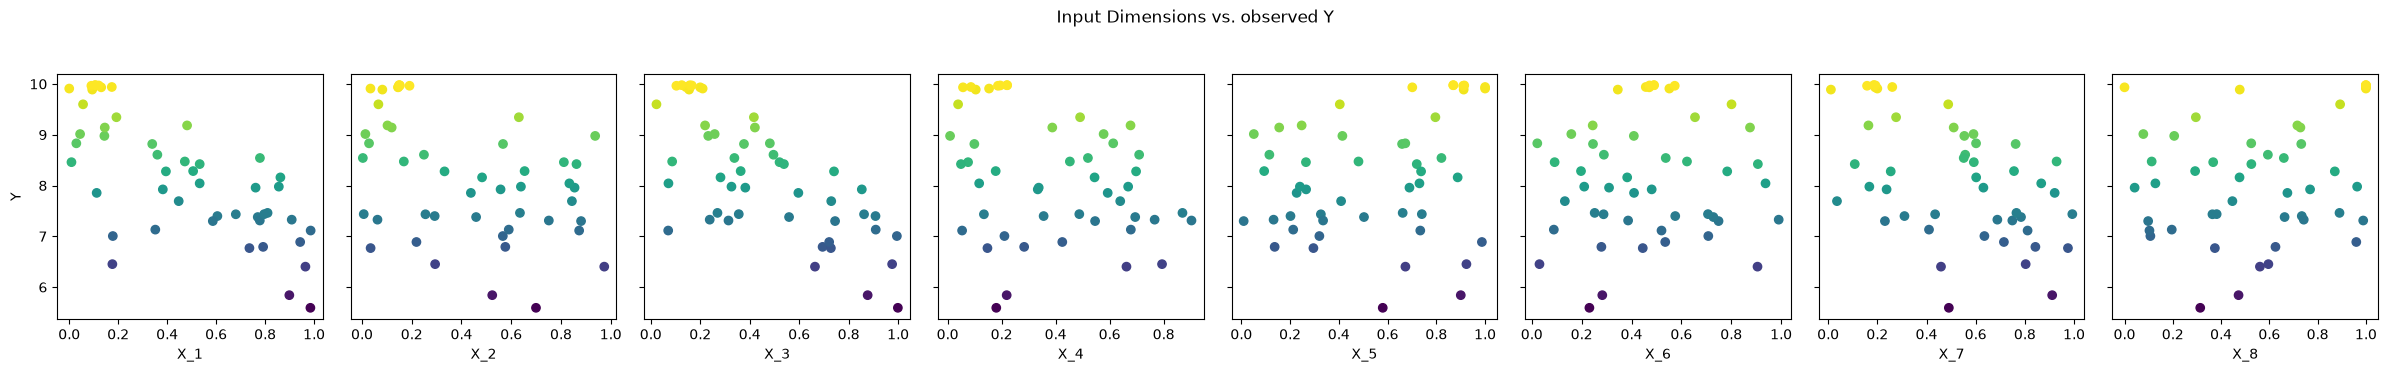

In [28]:
# Pairwise Scatter Plot, showing relationship of y for each input

fig, axes = plt.subplots(1, X.shape[1], figsize = (3 * X.shape[1], 3.5), sharey = True)
for ax, col in zip(axes, ['X_1','X_2','X_3','X_4','X_5','X_6','X_7','X_8']):
    ax.scatter(df[col], df['Y'], c = df['Y'], cmap = "viridis")
    ax.set_xlabel(col)
axes[0].set_ylabel('Y')
plt.suptitle("Input Dimensions vs. observed Y", y = 1.05)
plt.tight_layout()
plt.show()

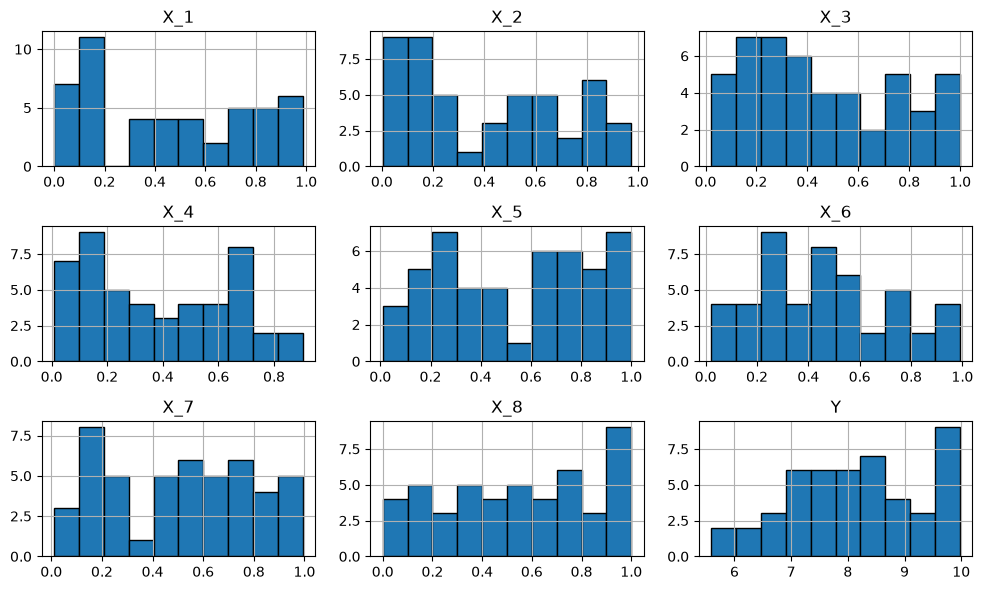

In [30]:
# Plot Histogram Visualisation for the columns of the DataFrame
df.hist(figsize = (10, 6), bins = 10, edgecolor = 'k' )
plt.tight_layout()
plt.show()

In [32]:
# Understanding Correlation between each input with y
labels      = ["X_1", "X_2", "X_3", "X_4", "X_5", "X_6", 'X_7','X_8']
print("Correlation of each input with y:\n")

for i, lab in enumerate(labels):
    corr = np.corrcoef(X[:, i], Y)[0, 1]
    print(f" corr({lab}, Y) = {corr}")

Correlation of each input with y:

 corr(X_1, Y) = -0.7352634318958486
 corr(X_2, Y) = -0.4366320609032248
 corr(X_3, Y) = -0.7200753699958674
 corr(X_4, Y) = -0.3186820582499693
 corr(X_5, Y) = 0.25246356299580874
 corr(X_6, Y) = 0.07097212762578475
 corr(X_7, Y) = -0.5442719729410301
 corr(X_8, Y) = 0.2787035339746942


<Axes: >

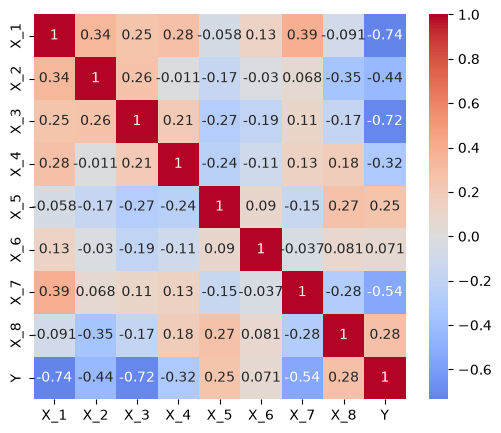

In [34]:
# Plotting the Correlation heatmap
plt.figure(figsize = (6,5))
sns.heatmap(df.corr(), annot = True, cmap = "coolwarm", center = 0)

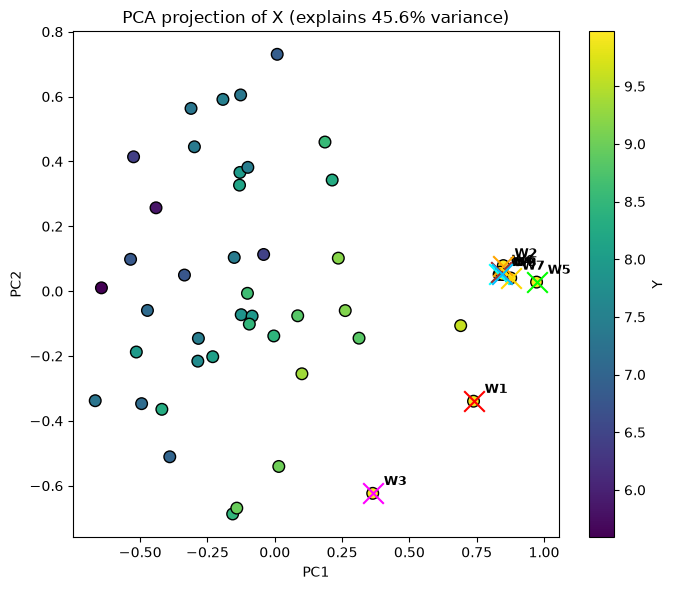

In [35]:
# Identify clustering of high-y points using PCA projection to 2D
pca            = PCA(n_components = 2)
X2             = pca.fit_transform(X)
fig, ax        = plt.subplots(figsize = (7, 6))

n_initial      = len(X0)
n_weeks_so_far = X.shape[0] - n_initial   
week_labels = np.array([0] * n_initial + list(range(1, n_weeks_so_far + 1)))

sc   = plt.scatter(X2[:, 0], X2[:, 1], c = Y, cmap = "viridis", s = 70, edgecolor = "k")

# Each week's query point: distinct marker/colour, annotated with its week number
markers = ["x", "x", "x", "x", "x", "x", "x", "x"]
colors  = ["red", "orange", "magenta", "cyan", "lime", "brown", "gold", "deepskyblue"]

for wk in range(1, n_weeks_so_far + 1):
    mask = week_labels == wk
    ax.scatter(X2[mask, 0], X2[mask, 1], c = colors[(wk - 1) % len(colors)], s = 220, edgecolor = "k", linewidth=1.5
               , marker = markers[(wk - 1) % len(markers)], label = f"Week {wk} query", zorder = 5)
    for xi, yi in zip(X2[mask, 0], X2[mask, 1]):
        ax.annotate(f"W{wk}", (xi, yi), textcoords = "offset points", xytext = (8, 6),
                    fontsize=9, fontweight = "bold")

plt.colorbar(sc, ax = ax, label = "Y")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title(f"PCA projection of X (explains {pca.explained_variance_ratio_.sum()*100:.1f}% variance)")
plt.tight_layout()
plt.show()

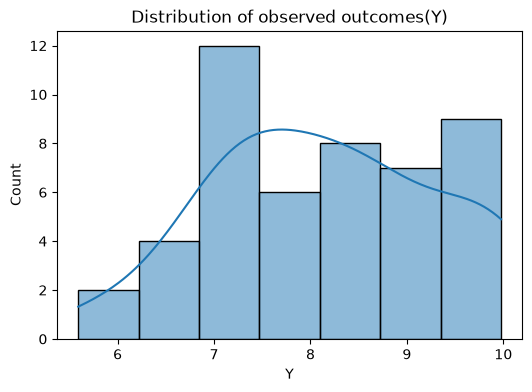

In [38]:
# Plot the Histogram for y to check for Outliers
plt.figure(figsize = (6,4))
sns.histplot(df['Y'], kde = True)
plt.title("Distribution of observed outcomes(Y)")
plt.show()

# Initialize Gaussian Process

In [41]:
#Define the kernel and initialise the GP model

kernel_rbf = ConstantKernel(1.0, (1e-2, 1e2)) * RBF(length_scale = np.ones(8), length_scale_bounds = (1e-2, 1e2)) \
                + WhiteKernel(noise_level = 1e-2, noise_level_bounds = (1e-8, 1e0))
gpr   = GaussianProcessRegressor(kernel = kernel_rbf, normalize_y = False, n_restarts_optimizer = 10, random_state = 42 )

# Fit the Gaussian Processes to existing data

In [44]:
# Train the model

gpr.fit(X, Y)
print("Learned kernel: ", gpr.kernel_)

Learned kernel:  2.26**2 * RBF(length_scale=[1.77, 2.51, 1.38, 2.58, 3.69, 2.63, 1.85, 100]) + WhiteKernel(noise_level=1e-08)


# Compute the UCB acquisition function

- UCB(x)=μ(x)+β⋅σ(x)
- A high beta favors exploration (uncertainty) over exploitation (predicted mean).
- Week 1 uses beta = 2.5, reflecting the 90:10 exploration-heavy strategy.

In [47]:
# Setting a higher beta(= 2.0) for Week -1
beta          = 2.0    # Week 1

# Function to calculatee UCB 
def ucb(X_query, gpr, beta):
    mu, std   = gpr.predict(X_query, return_std = True)
    return mu + beta * std

n_points, n_dims = X.shape
rng_seed      = 42
n_candidates  = 10000
sampler       = qmc.LatinHypercube(d = n_dims, seed = rng_seed)
candidates    = sampler.random(n = n_candidates) 

ucb_values    = ucb(candidates, gpr, beta)
best_ucb_idx  = np.argmax(ucb_values)
next_point    = candidates[best_ucb_idx]

print(f"Suggested next Query Point: {next_point}")
print(f"UCB Score: {ucb_values[best_ucb_idx]:.6e}")

Suggested next Query Point: [0.18306279 0.12509282 0.13107799 0.28875332 0.65180096 0.61390037
 0.17910204 0.70515769]
UCB Score: 9.949985e+00


# Week 2: Consolidated Bayesian Optimisation Function

In [51]:
def upper_confidence_bound(mu, sigma, beta = 2.0):
    """UCB(x) = mu(x) + beta * sigma(x). Higher beta => more exploration."""
    return mu + beta * sigma
    
def expected_improvement(mu, sigma, y_best, xi = 0.01):
    """EI(x) = E[max(f(x) - f(x_best) - xi, 0)]."""
    with np.errstate(divide = "warn"):
        improvement = mu - y_best - xi
        Z           = improvement / sigma
        ei          = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return ei

def suggest_next_point( X_samples, y_samples, n_dims = 8, acquisition = "ucb", beta = 1.5,
                        xi = 0.01, n_restarts = 20, random_state = 42,
                        length_scale_bounds = (1e-2, 1e2), noise_bounds = (1e-8, 1e0)):

    rng    = np.random.default_rng(random_state)
    
    bounds = [(0.0, 0.999999)] * n_dims

    kernel = ConstantKernel(1.0, (1e-2, 1e2)) * RBF(length_scale = np.ones(n_dims), length_scale_bounds = length_scale_bounds) \
                + WhiteKernel(noise_level = 1e-2, noise_level_bounds = noise_bounds)
   
    gp     = GaussianProcessRegressor(kernel = kernel, normalize_y = False, n_restarts_optimizer = 10, random_state = random_state)
    
    gp.fit(X_samples, y_samples)

    y_best = y_samples.max()

    def acq_objective(x):
        x         = x.reshape(1, -1)    
        mu, sigma = gp.predict(x, return_std=True)
        
        if acquisition == "ei":
            val   = expected_improvement(mu, sigma, y_best, xi = xi)
        else:
            val   = upper_confidence_bound(mu, sigma, beta = beta)
        
        return - val[0]  # minimise the negative -> maximise the acquisition

    best_val = np.inf
    X_next   = None
    for _ in range(n_restarts):
        x0   = rng.uniform(0, 0.999999, n_dims)
        res  = minimize(acq_objective, x0, bounds = bounds, method = "L-BFGS-B")
        if res.fun < best_val:
            best_val = res.fun
            X_next   = res.x

    mu_next, sigma_next = gp.predict(X_next.reshape(1, -1), return_std = True)
    return X_next, gp, mu_next[0], sigma_next[0], - best_val


In [53]:
beta    = 1.5

X_next, gp_week2, mu_next, sigma_next, acq_val = suggest_next_point(  X, Y, n_dims = 8, acquisition = "ucb", 
                                                                      beta = beta, n_restarts = 20, random_state = 42
                                                                    )

print(f"Week 2 next query point: {np.round(X_next, 6)}")
print(f"Predicted mean  : {mu_next:.4f}")
print(f"Predicted std   : {sigma_next:.4f}")
print(f"UCB acquisition : {acq_val:.4f}  (beta = {beta})")

Week 2 next query point: [0.109443 0.086864 0.122221 0.222325 0.888124 0.528026 0.186352 0.      ]
Predicted mean  : 9.9649
Predicted std   : 0.0170
UCB acquisition : 9.9905  (beta = 1.5)


# Week 3: Get Query Point

In [55]:
# lowered beta from 1.5 to 1.0
beta_week3 = 1.0  

X_next, gp_week3, mu_next, sigma_next, acq_val = suggest_next_point(
    X, Y, n_dims = 8, acquisition = "ucb", beta = beta_week3, n_restarts = 20, random_state = 42
)

print(f"Week 3 next query point: {np.round(X_next, 6)}")
print(f"Predicted mean         : {mu_next:.4f}")
print(f"Predicted std          : {sigma_next:.4f}")
print(f"UCB acquisition        : {acq_val:.4f}  (beta = {beta_week3})")

Week 3 next query point: [0.077062 0.146421 0.126983 0.148172 0.806898 0.478991 0.195286 0.999999]
Predicted mean         : 9.9769
Predicted std          : 0.0082
UCB acquisition        : 9.9851  (beta = 1.0)


# Week 3: Perform Visualisation

In [58]:
# Identify the two most-correlated input dims (for slicing/plotting)
corrs      = np.array([np.corrcoef(X[:, i], Y)[0, 1] for i in range(X.shape[1])])
top2       = np.argsort(-np.abs(corrs))[:2]
da, db     = int(top2[0]), int(top2[1])
print(f"Slicing through x{da+1} and x{db+1} (most correlated with Y)")

incumbent  = X[Y.argmax()].copy()

res_grid   = 60
grid_1d    = np.linspace(0, 1, res_grid)
A, B       = np.meshgrid(grid_1d, grid_1d)
pts        = np.tile(incumbent, (res_grid * res_grid, 1))
pts[:, da] = A.ravel()
pts[:, db] = B.ravel()

mu_grid, sigma_grid = gp_week3.predict(pts, return_std=True)
Z_mean    = mu_grid.reshape(res_grid, res_grid)
Z_ucb     = (mu_grid + beta_week3 * sigma_grid).reshape(res_grid, res_grid)

Slicing through x1 and x3 (most correlated with Y)


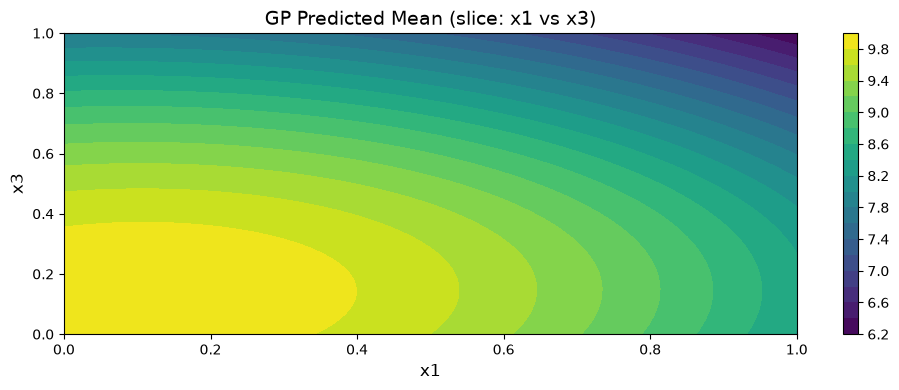

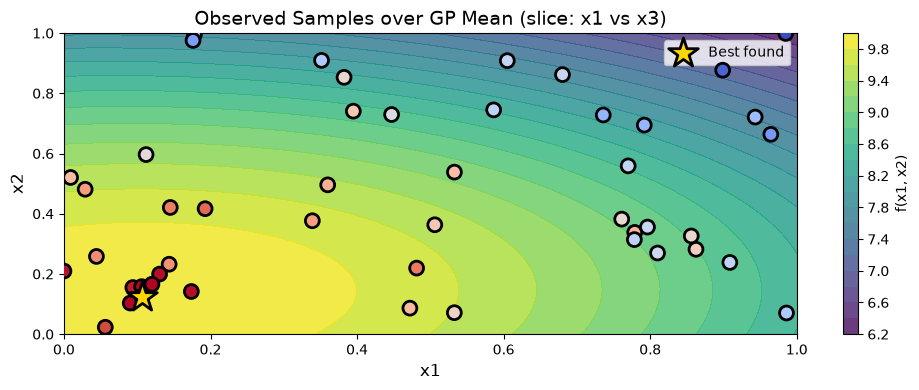

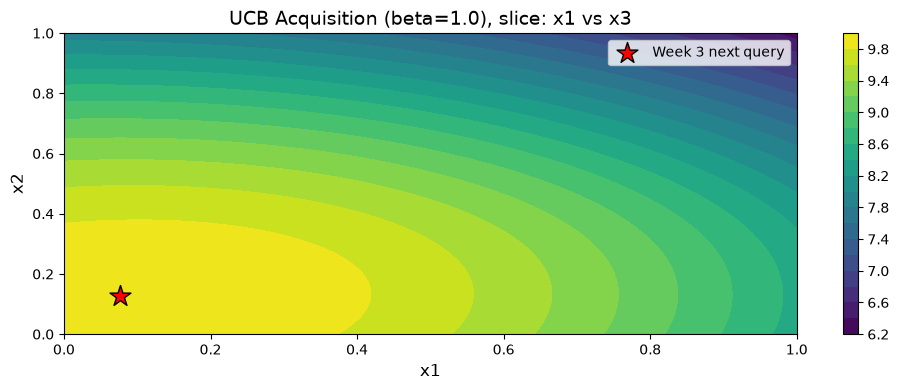

In [59]:
# GP predicted mean surface (using plotting_utils.plot_2d_function)
fig, ax = plot_2d_function(A, B, Z_mean, title=f"GP Predicted Mean (slice: x{da+1} vs x{db+1})")
ax.set_xlabel(f"x{da+1}"); ax.set_ylabel(f"x{db+1}")
plt.show()

# Observed samples overlaid on the GP mean surface (using plotting_utils.plot_2d_bo_state)
fig, ax = plot_2d_bo_state(A, B, Z_mean, X[:, [da, db]], Y,
                            title=f"Observed Samples over GP Mean (slice: x{da+1} vs x{db+1})")
plt.show()

# UCB acquisition surface with the Week 3 query point marked
fig, ax = plot_2d_function(A, B, Z_ucb, title=f"UCB Acquisition (beta={beta_week3}), slice: x{da+1} vs x{db+1}")
ax.scatter(X_next[da], X_next[db], marker="*", c="red", s=250, edgecolor="k", label="Week 3 next query")
ax.legend()
plt.show()

# Week 4: Calling the consolidated Bayesian Function with lowered β( = 0.7 )

In [63]:
beta_week4 = 0.7   # lowered from Week 3's 1.0 -- see rationale above

X_next, gp_week4, mu_next, sigma_next, acq_val = suggest_next_point(
    X, Y, n_dims=8, acquisition="ucb", beta=beta_week4, n_restarts=20, random_state=42
)

print(f"Week 4 next query point: {np.round(X_next, 6)}")
print(f"Predicted mean         : {mu_next:.4f}")
print(f"Predicted std          : {sigma_next:.4f}")
print(f"UCB acquisition        : {acq_val:.4f}  (beta = {beta_week4})")

Week 4 next query point: [0.085479 0.136077 0.127294 0.156055 0.812882 0.486356 0.193955 0.999999]
Predicted mean         : 9.9785
Predicted std          : 0.0063
UCB acquisition        : 9.9830  (beta = 0.7)


# Perform Visualisation

In [66]:
# Identify the two most-correlated input dims (for slicing/plotting)
corrs      = np.array([np.corrcoef(X[:, i], Y)[0, 1] for i in range(X.shape[1])])
top2       = np.argsort(-np.abs(corrs))[:2]
da, db     = int(top2[0]), int(top2[1])
print(f"Slicing through x{da+1} and x{db+1} (most correlated with Y)")

incumbent  = X[Y.argmax()].copy()

res_grid   = 60
grid_1d    = np.linspace(0, 1, res_grid)
A, B       = np.meshgrid(grid_1d, grid_1d)
pts        = np.tile(incumbent, (res_grid * res_grid, 1))
pts[:, da] = A.ravel()
pts[:, db] = B.ravel()

mu_grid, sigma_grid = gp_week4.predict(pts, return_std=True)
Z_mean    = mu_grid.reshape(res_grid, res_grid)
Z_ucb     = (mu_grid + beta_week4 * sigma_grid).reshape(res_grid, res_grid)

Slicing through x1 and x3 (most correlated with Y)


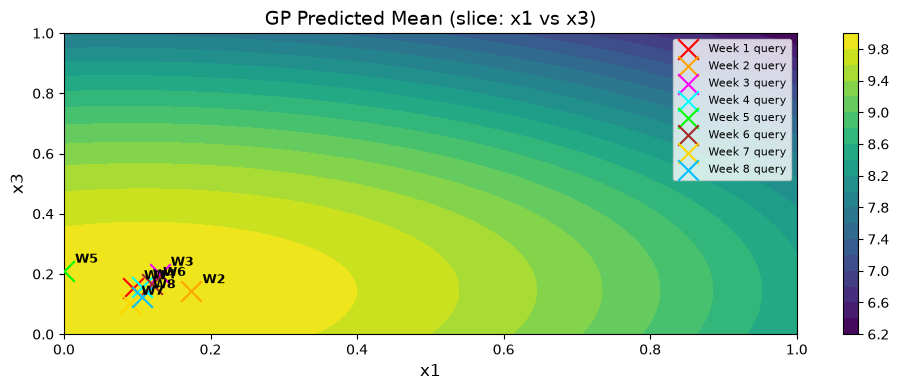

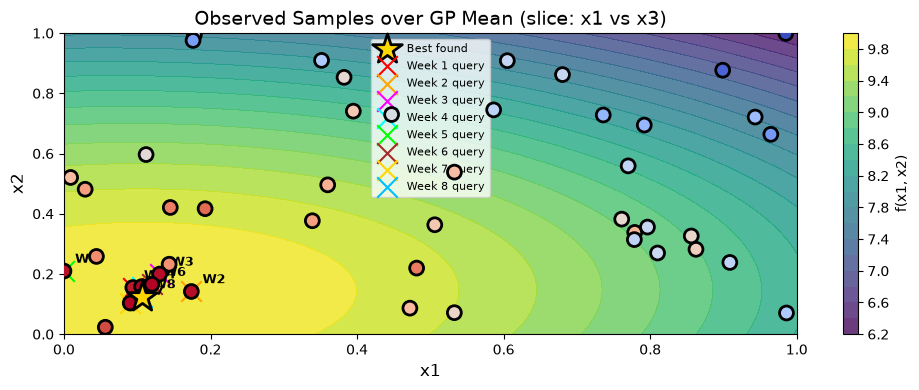

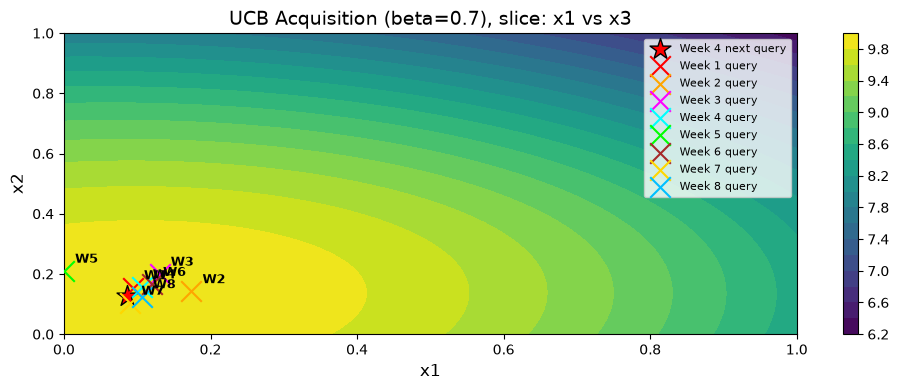

In [67]:
n_initial = len(X0)
n_weeks_so_far = X.shape[0] - n_initial   # e.g. 3 after Week 3 is appended
week_labels = np.array([0] * n_initial + list(range(1, n_weeks_so_far + 1)))

markers = ["x", "x", "x", "x", "x", "x", "x", "x"]
colors  = ["red", "orange", "magenta", "cyan", "lime", "brown", "gold", "deepskyblue"]

def highlight_weekly_points(ax, dim_a, dim_b):
    """Overlay each week's query point (columns dim_a, dim_b of X) on the given axes."""
    for wk in range(1, n_weeks_so_far + 1):
        mask = week_labels == wk
        ax.scatter(X[mask, dim_a], X[mask, dim_b], c=colors[(wk - 1) % len(colors)], s=220,
                   edgecolor="k", linewidth=1.5, marker=markers[(wk - 1) % len(markers)],
                   label=f"Week {wk} query", zorder=6)
        for xi, yi in zip(X[mask, dim_a], X[mask, dim_b]):
            ax.annotate(f"W{wk}", (xi, yi), textcoords="offset points", xytext=(8, 6),
                        fontsize=9, fontweight="bold", zorder=7)


# GP predicted mean surface (using plotting_utils.plot_2d_function)
fig, ax = plot_2d_function(A, B, Z_mean, title=f"GP Predicted Mean (slice: x{da+1} vs x{db+1})")
ax.set_xlabel(f"x{da+1}"); ax.set_ylabel(f"x{db+1}")
highlight_weekly_points(ax, da, db)
ax.legend(fontsize=8)
plt.show()

# Observed samples overlaid on the GP mean surface (using plotting_utils.plot_2d_bo_state)
fig, ax = plot_2d_bo_state(A, B, Z_mean, X[:, [da, db]], Y,
                            title=f"Observed Samples over GP Mean (slice: x{da+1} vs x{db+1})")
highlight_weekly_points(ax, da, db)
ax.legend(fontsize=8)
plt.show()

# UCB acquisition surface with the Week 4 query point marked
fig, ax = plot_2d_function(A, B, Z_ucb, title=f"UCB Acquisition (beta={beta_week4}), slice: x{da+1} vs x{db+1}")
ax.scatter(X_next[da], X_next[db], marker="*", c="red", s=250, edgecolor="k", label="Week 4 next query")
highlight_weekly_points(ax, da, db)
ax.legend(fontsize=8)
plt.show()

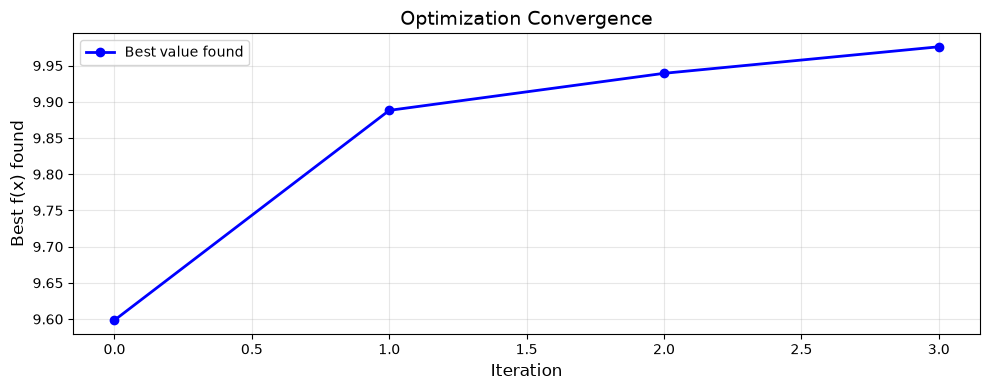

Best after Week 0 (initial data): 9.598482
Best after Week 1:                9.888207
Best after Week 2:                9.939383
Best after Week 3:                9.976026


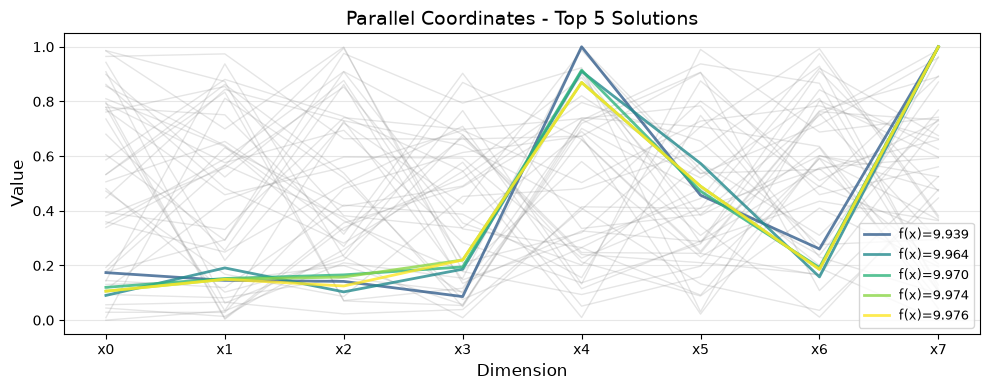

In [68]:
# Convergence: best value found at the end of each week
best_week0 = Y0.max()                                    # best of the original 40 points
best_week1 = max(best_week0, Y_w1_new_point[0])
best_week2 = max(best_week1, Y_w2_new_point[0])
best_week3 = Y.max()                                      # best after appending W1+W2+W3

plot_convergence([0, 1, 2, 3], [best_week0, best_week1, best_week2, best_week3])
plt.show()

print(f"Best after Week 0 (initial data): {best_week0:.6f}")
print(f"Best after Week 1:                {best_week1:.6f}")
print(f"Best after Week 2:                {best_week2:.6f}")
print(f"Best after Week 3:                {best_week3:.6f}")

# Parallel coordinates: how do the top 5 solutions compare across all 8 dimensions?
plot_parallel_coordinates(X, Y, n_best=5)
plt.show()

# Week 5: Strategy Review
Weeks 1-4 followed a single monotone plan: keep lowering β (2.0 → 1.5 → 1.0 → 0.7) and let the GP exploit. Week 4 produced a new best (9.973776), so the natural next step would be β = 0.5. **The diagnostics below show that would be the wrong move.** 

In [72]:
from scipy.stats import qmc

probe          = qmc.LatinHypercube(d = 8, seed = 7).random(50000)
mu_probe, sg_probe = gpr.predict(probe, return_std = True)

print(f"Current best observed y      : {Y.max():.6f}")
print(f"Best GP-predicted mu anywhere: {mu_probe.max():.6f}")
print(f"Fraction of space where mu > y_best: {(mu_probe > Y.max()).mean():.5f}")
print()
_, sigma_at_incumbent = gpr.predict(X[Y.argmax()].reshape(1, -1), return_std = True)
print(f"GP sigma at the incumbent    : {sigma_at_incumbent[0]:.6f}")
print(f"Learned noise level          : {gpr.kernel_.k2.noise_level:.2e}")

Current best observed y      : 9.976026
Best GP-predicted mu anywhere: 9.943179
Fraction of space where mu > y_best: 0.00000

GP sigma at the incumbent    : 0.000142
Learned noise level          : 1.00e-08


In [74]:
# Checking how x8 contributes
ls_learned = gpr.kernel_.k1.k2.length_scale
print("ARD length scales (short = influential, long = irrelevant):")
for i in np.argsort(ls_learned):
    print(f"  x{i+1}: {ls_learned[i]:.3f}")

print("\nx8 across weekly queries so far:")
for wk, pt in enumerate([X_w1_new_point, X_w2_new_point, X_w3_new_point, X_w4_new_point], start = 1):
    print(f"  Week {wk}: x8 = {pt[7]:.6f}")

ARD length scales (short = influential, long = irrelevant):
  x3: 1.380
  x1: 1.774
  x7: 1.847
  x2: 2.508
  x4: 2.581
  x6: 2.629
  x5: 3.688
  x8: 100.000

x8 across weekly queries so far:
  Week 1: x8 = 0.477351
  Week 2: x8 = 0.999999
  Week 3: x8 = 0.000000
  Week 4: x8 = 0.999999


**Observations:**
1. **The surrogate has saturated.** The GP predicts that *nothing anywhere in the space* beats the current incumbent. Expected Improvement would therefore be identically zero everywhere, making EI unusable as an acquisition function this week. UCB with a small β simply re-samples within ~0.1 of the incumbent, i.e. it would spend a query confirming what the model already believes.
2. **That confidence is not trustworthy.** The learned noise level keeps collapsing to its lower bound and σ at the incumbent is ~1e-4, meaning the GP is *interpolating* 44 points rather than regularising them. A model this certain, on this little data in 8D, is over-confident - and Week 3 already gave us empirical proof (predicted 9.995, actual 9.933). So "nothing beats the incumbent" is an extrapolation from data that all sits in one corner of the space, not evidence.
3. **x8 is a nuisance dimension.** Its length scale has run away to the upper bound (~1e3): the GP detects *no* relationship between x8 and Y. The optimiser has been flip-flopping it between the extremes (0.477 → 0.999999 → 0.000000 → 0.999999) purely because the acquisition surface is flat along that axis. Worse, when we search for distinct local optima of the GP mean, the "different" optima returned are **identical in x1–x7 and differ only in x8**.

# Week 5: Strategy Change
| | Weeks 1-4 | Week 5 |
|---|---|---|
| β | 2.0 → 0.7 (monotone decrease) | **3.0** (deliberate increase) |
| x8 | free | **frozen** at the incumbent value |
| Noise floor | 1e-8 (collapses → interpolation) | **1e-4** (forces regularisation, restores honest σ) |
| Intent | exploitation | **one exploration probe** |

**Why raise β rather than lower it.** Exploitation is exhausted: The model has no signal pointing uphill. The capstone brief notes that one function has two optima, and we would have no way of knowing whether Function 8 is the one. If the probe returns a poor value we lose one query and have *confirmed* the basin, which is itself worth knowing. If it returns a high value we have found a second region with few weeks left to refine it.

**Why β = 3.0 and not higher.** A β sweep showed β ≤ 2.0 stays within 0.09 of the incumbent, while β = 8 lands on a point with predicted mean ≈ 8.95. β = 3.0 steps a meaningful distance away while keeping the predicted mean around 9.9, which would indicate a controlled probe.

In [80]:
kernel_week5 = ConstantKernel(1.0, (1e-2, 1e2)) * RBF(length_scale = np.ones(8), length_scale_bounds = (1e-2, 1e3)) \
                 + WhiteKernel(noise_level = 1e-2, noise_level_bounds = (1e-4, 1e0))   # <-- floor raised

gp_week5 = GaussianProcessRegressor(kernel = kernel_week5, normalize_y = False,
                                     n_restarts_optimizer = 10, random_state = 42)
gp_week5.fit(X, Y)

print("Week 5 kernel:", gp_week5.kernel_)
_, s_new = gp_week5.predict(X[Y.argmax()].reshape(1, -1), return_std = True)
print(f"sigma at incumbent: {s_new[0]:.5f}   (was ~0.0001 with the 1e-8 floor)")

Week 5 kernel: 2.18**2 * RBF(length_scale=[1.75, 2.48, 1.36, 2.47, 3.89, 2.54, 1.87, 1e+03]) + WhiteKernel(noise_level=0.0001)
sigma at incumbent: 0.01181   (was ~0.0001 with the 1e-8 floor)


In [81]:
beta_week5 = 3.0                       # raised from Week 4's 0.7
incumbent5 = X[Y.argmax()].copy()
X8_FIXED   = incumbent5[7]             # freeze the nuisance dimension
REL_DIMS   = [0, 1, 2, 3, 4, 5, 6]     # x1..x7 carry the signal

# Global candidate pool over x1..x7, with x8 held fixed
lhs_7d     = qmc.LatinHypercube(d = 7, seed = 7).random(200000)
cand       = np.hstack([lhs_7d, np.full((len(lhs_7d), 1), X8_FIXED)])

mu_c, sg_c = gp_week5.predict(cand, return_std = True)
ucb_c      = mu_c + beta_week5 * sg_c
seed_pt    = cand[ucb_c.argmax()]

# Polish with L-BFGS-B, keeping x8 pinned
def neg_ucb_w5(x):
    x      = x.reshape(1, -1)
    m, s   = gp_week5.predict(x, return_std = True)
    return -(m + beta_week5 * s)[0]

bounds_w5  = [(0.0, 0.999999)] * 7 + [(X8_FIXED, X8_FIXED)]
res_w5     = minimize(neg_ucb_w5, seed_pt, bounds = bounds_w5, method = "L-BFGS-B")
X_next     = res_w5.x

mu_next, sigma_next = gp_week5.predict(X_next.reshape(1, -1), return_std = True)
dist_rel   = np.linalg.norm(X_next[REL_DIMS] - incumbent5[REL_DIMS])

print(f"Week 5 next query point: {np.round(X_next, 6)}")
print(f"Predicted mean         : {mu_next[0]:.4f}")
print(f"Predicted std          : {sigma_next[0]:.4f}   (vs ~0.01 for a greedy query)")
print(f"Distance from incumbent (x1-x7): {dist_rel:.3f}")
print(f"beta = {beta_week5}, x8 frozen at {X8_FIXED:.6f}")

Week 5 next query point: [0.170511 0.072086 0.155033 0.232929 0.954142 0.574258 0.131702 0.999999]
Predicted mean         : 9.9466
Predicted std          : 0.0241   (vs ~0.01 for a greedy query)
Distance from incumbent (x1-x7): 0.169
beta = 3.0, x8 frozen at 0.999999


# Week 5: Visualisation

In [83]:
ls5        = gp_week5.kernel_.k1.k2.length_scale
da, db     = np.argsort(ls5)[:2]                 # shortest length scales = most influential
da, db     = int(da), int(db)
print(f"Slicing through x{da+1} and x{db+1} (shortest ARD length scales)")

res_grid   = 60
grid_1d    = np.linspace(0, 1, res_grid)
A, B       = np.meshgrid(grid_1d, grid_1d)
pts        = np.tile(incumbent5, (res_grid * res_grid, 1))
pts[:, da] = A.ravel()
pts[:, db] = B.ravel()

mu_grid, sigma_grid = gp_week5.predict(pts, return_std = True)
Z_mean     = mu_grid.reshape(res_grid, res_grid)
Z_sigma    = sigma_grid.reshape(res_grid, res_grid)
Z_ucb      = (mu_grid + beta_week5 * sigma_grid).reshape(res_grid, res_grid)

Slicing through x3 and x1 (shortest ARD length scales)


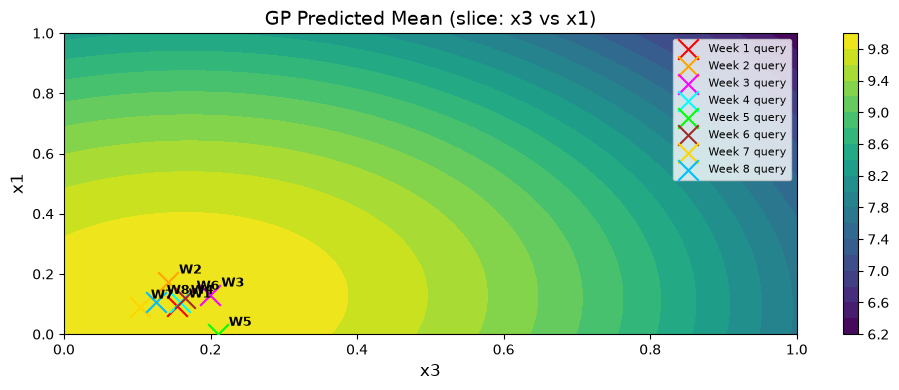

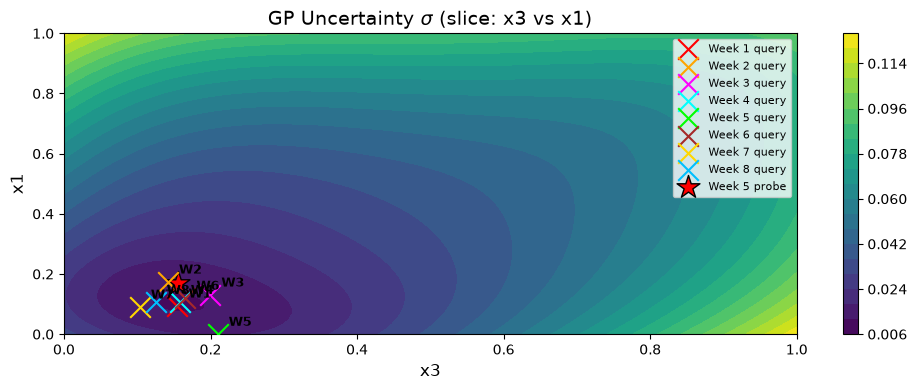

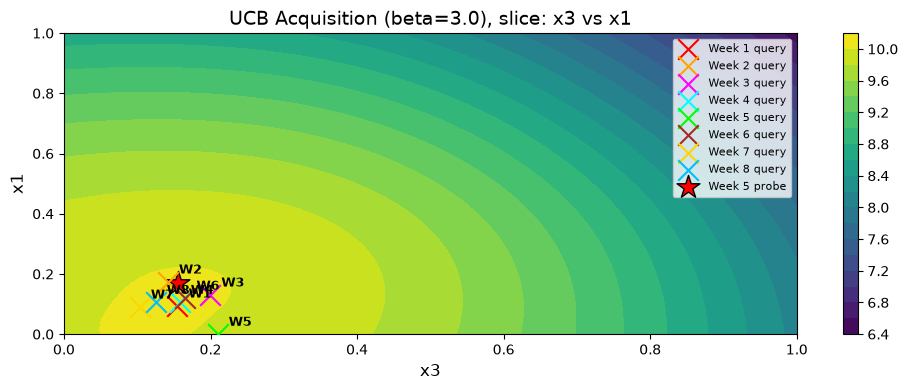

In [84]:
# GP mean
fig, ax = plot_2d_function(A, B, Z_mean, title = f"GP Predicted Mean (slice: x{da+1} vs x{db+1})")
ax.set_xlabel(f"x{da+1}"); ax.set_ylabel(f"x{db+1}")
highlight_weekly_points(ax, da, db)
ax.legend(fontsize = 8)
plt.show()

# Uncertainty surface -- shows WHERE the model is still ignorant (drives this week's probe)
fig, ax = plot_2d_function(A, B, Z_sigma, title = f"GP Uncertainty $\\sigma$ (slice: x{da+1} vs x{db+1})")
ax.set_xlabel(f"x{da+1}"); ax.set_ylabel(f"x{db+1}")
highlight_weekly_points(ax, da, db)
ax.scatter(X_next[da], X_next[db], marker = "*", c = "red", s = 300, edgecolor = "k", label = "Week 5 probe")
ax.legend(fontsize = 8)
plt.show()

# UCB with the Week 5 probe marked
fig, ax = plot_2d_function(A, B, Z_ucb, title = f"UCB Acquisition (beta={beta_week5}), slice: x{da+1} vs x{db+1}")
ax.set_xlabel(f"x{da+1}"); ax.set_ylabel(f"x{db+1}")
highlight_weekly_points(ax, da, db)
ax.scatter(X_next[da], X_next[db], marker = "*", c = "red", s = 300, edgecolor = "k", label = "Week 5 probe")
ax.legend(fontsize = 8)
plt.show()

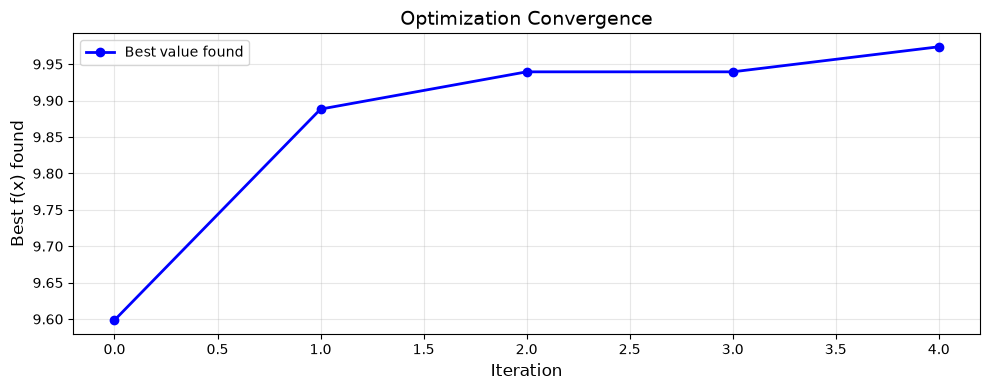

Best after Week 0: 9.598482
Best after Week 1: 9.888207
Best after Week 2: 9.939383
Best after Week 3: 9.939383
Best after Week 4: 9.973776


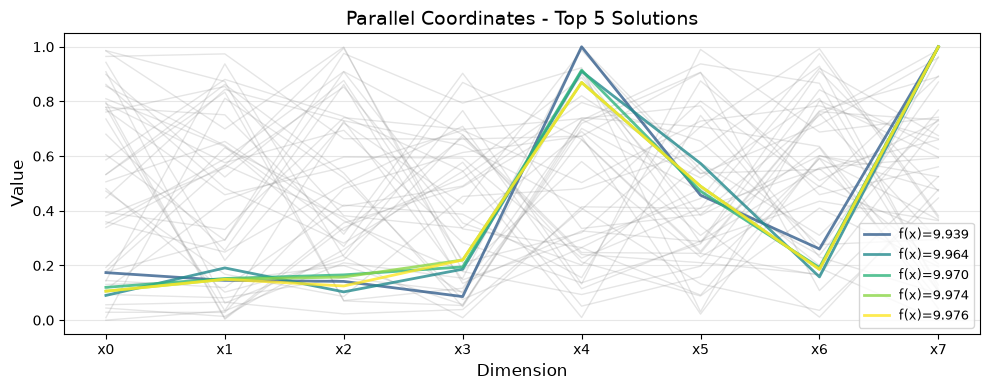

In [85]:
# Convergence
best_week0 = Y0.max()
best_week1 = max(best_week0, Y_w1_new_point[0])
best_week2 = max(best_week1, Y_w2_new_point[0])
best_week3 = max(best_week2, Y_w3_new_point[0])
best_week4 = max(best_week3, Y_w4_new_point[0])

plot_convergence([0, 1, 2, 3, 4], [best_week0, best_week1, best_week2, best_week3, best_week4])
plt.show()

for wk, v in enumerate([best_week0, best_week1, best_week2, best_week3, best_week4]):
    print(f"Best after Week {wk}: {v:.6f}")

plot_parallel_coordinates(X, Y, n_best = 5)
plt.show()

# Week 6: Strategy Review

In [90]:
# Determining the headroom left in the basin
kernel_week6 = ConstantKernel(1.0, (1e-2, 1e2)) * RBF(length_scale = np.ones(8), length_scale_bounds = (1e-2, 1e3)) \
                 + WhiteKernel(noise_level = 1e-2, noise_level_bounds = (1e-4, 1e0))   # floor kept at 1e-4

gp_week6 = GaussianProcessRegressor(kernel = kernel_week6, normalize_y = False,
                                     n_restarts_optimizer = 10, random_state = 42)
gp_week6.fit(X, Y)
print("Week 6 kernel:", gp_week6.kernel_)

incumbent6 = X[Y.argmax()].copy()
X8_FIXED   = incumbent6[7]

# Scan the space (x8 frozen) and ask how much the model thinks is still available
scan       = np.hstack([qmc.LatinHypercube(d = 7, seed = 11).random(200000),
                        np.full((200000, 1), X8_FIXED)])
mu_s, sg_s = gp_week6.predict(scan, return_std = True)

print(f"\nBest observed y            : {Y.max():.6f}")
print(f"Best GP mean anywhere      : {mu_s.max():.6f}  ({mu_s.max() - Y.max():+.6f})")
print(f"Fraction with mu > y_best  : {(mu_s > Y.max()).mean():.6f}")
print(f"Fraction with UCB(0.5) > y_best : {((mu_s + 0.5 * sg_s) > Y.max()).mean():.6f}")

Week 6 kernel: 2.18**2 * RBF(length_scale=[1.75, 2.48, 1.36, 2.47, 3.89, 2.54, 1.87, 1e+03]) + WhiteKernel(noise_level=0.0001)

Best observed y            : 9.976026
Best GP mean anywhere      : 9.944299  (-0.031727)
Fraction with mu > y_best  : 0.000000
Fraction with UCB(0.5) > y_best : 0.000000


**Observation: The basin is a plateau, not a peak.** The GP's best predicted mean anywhere is *below* the value we already hold, and even an optimistic UCB(β = 0.5) bound clears the incumbent nowhere in 200,000 sampled points. Scanning individual dimensions through the incumbent shows why the surface is genuinely flat near the top (x5 moves 0.87 → 1.00 for a change of only 0.0025 in predicted mean; x4 is flat across 0.15 → 0.22).

This is the honest position going into the final weeks: **expected remaining gain in this basin is on the order of a few thousandths**, and the realistic upside comes from the model's residual uncertainty (σ ≈ 0.012) rather than from any predicted improvementHence, . Week poling would be more towards a refing thent que point.h.

In [93]:
beta_week6 = 0.5                       # was 3.0 in Week 5's probe
REL_DIMS   = [0, 1, 2, 3, 4, 5, 6]

ucb_scan   = mu_s + beta_week6 * sg_s
seed_pt    = scan[ucb_scan.argmax()]

def neg_ucb_w6(x):
    x    = x.reshape(1, -1)
    m, s = gp_week6.predict(x, return_std = True)
    return -(m + beta_week6 * s)[0]

bounds_w6  = [(0.0, 0.999999)] * 7 + [(X8_FIXED, X8_FIXED)]
res_w6     = minimize(neg_ucb_w6, seed_pt, bounds = bounds_w6, method = "L-BFGS-B")
X_next     = res_w6.x

mu_next, sigma_next = gp_week6.predict(X_next.reshape(1, -1), return_std = True)

print(f"Week 6 next query point: {np.round(X_next, 6)}")
print(f"Predicted mean         : {mu_next[0]:.4f}   (incumbent {Y.max():.4f}, so {mu_next[0]-Y.max():+.4f})")
print(f"Predicted std          : {sigma_next[0]:.4f}")
print(f"Distance from incumbent (x1-x7): {np.linalg.norm(X_next[REL_DIMS] - incumbent6[REL_DIMS]):.3f}")
print(f"beta = {beta_week6}, x8 frozen at {X8_FIXED:.6f}")

Week 6 next query point: [0.113526 0.158444 0.152302 0.19048  0.896708 0.496129 0.189037 0.999999]
Predicted mean         : 9.9769   (incumbent 9.9760, so +0.0009)
Predicted std          : 0.0109
Distance from incumbent (x1-x7): 0.050
beta = 0.5, x8 frozen at 0.999999


# Week 6: Visualisation

In [96]:
ls6        = gp_week6.kernel_.k1.k2.length_scale
da, db     = [int(v) for v in np.argsort(ls6)[:2]]
print(f"Slicing through x{da+1} and x{db+1} (shortest ARD length scales)")

res_grid   = 60
grid_1d    = np.linspace(0, 1, res_grid)
A, B       = np.meshgrid(grid_1d, grid_1d)
pts        = np.tile(incumbent6, (res_grid * res_grid, 1))
pts[:, da] = A.ravel()
pts[:, db] = B.ravel()

mu_grid, sigma_grid = gp_week6.predict(pts, return_std = True)
Z_mean     = mu_grid.reshape(res_grid, res_grid)
Z_sigma    = sigma_grid.reshape(res_grid, res_grid)
Z_ucb      = (mu_grid + beta_week6 * sigma_grid).reshape(res_grid, res_grid)

Slicing through x3 and x1 (shortest ARD length scales)


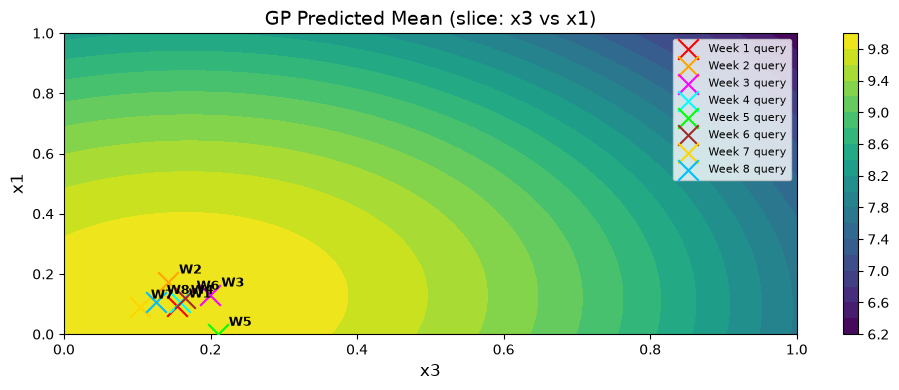

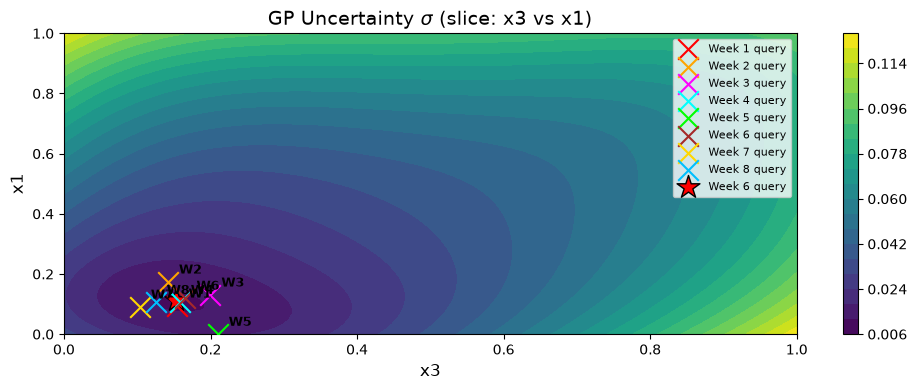

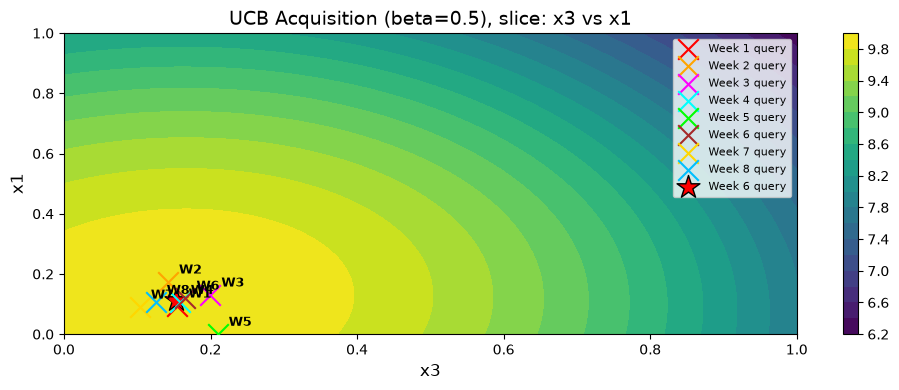

In [97]:
fig, ax = plot_2d_function(A, B, Z_mean, title = f"GP Predicted Mean (slice: x{da+1} vs x{db+1})")
ax.set_xlabel(f"x{da+1}"); ax.set_ylabel(f"x{db+1}")
highlight_weekly_points(ax, da, db)
ax.legend(fontsize = 8); plt.show()

fig, ax = plot_2d_function(A, B, Z_sigma, title = f"GP Uncertainty $\\sigma$ (slice: x{da+1} vs x{db+1})")
ax.set_xlabel(f"x{da+1}"); ax.set_ylabel(f"x{db+1}")
highlight_weekly_points(ax, da, db)
ax.scatter(X_next[da], X_next[db], marker = "*", c = "red", s = 300, edgecolor = "k", label = "Week 6 query")
ax.legend(fontsize = 8); plt.show()

fig, ax = plot_2d_function(A, B, Z_ucb, title = f"UCB Acquisition (beta={beta_week6}), slice: x{da+1} vs x{db+1}")
ax.set_xlabel(f"x{da+1}"); ax.set_ylabel(f"x{db+1}")
highlight_weekly_points(ax, da, db)
ax.scatter(X_next[da], X_next[db], marker = "*", c = "red", s = 300, edgecolor = "k", label = "Week 6 query")
ax.legend(fontsize = 8); plt.show()

Week  Pred      Sigma    Actual      Error      z       Inside 1σ?
3     9.9950    0.0320   9.933047    -0.0620    -1.94   NO
4     9.9810    0.0210   9.973776    -0.0072    -0.34   yes
5     9.9170    0.0460   9.908828    -0.0082    -0.18   yes

Week 3 ran with the 1e-8 noise floor; Weeks 4-5 with regularisation applied.


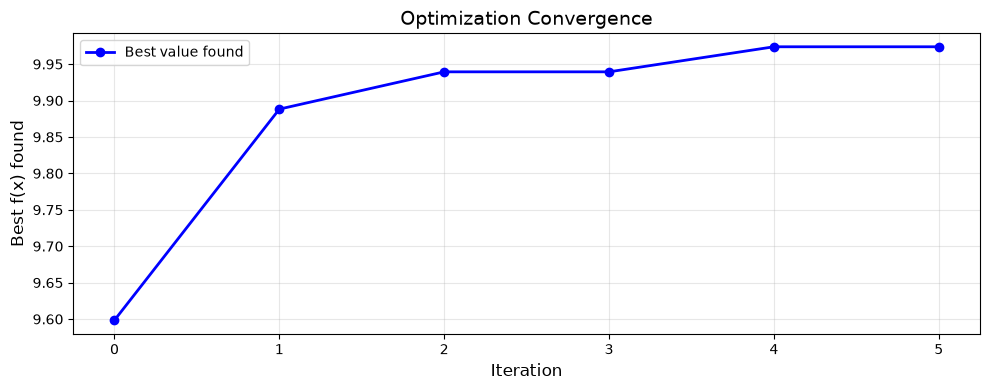

Best after Week 0: 9.598482
Best after Week 1: 9.888207
Best after Week 2: 9.939383
Best after Week 3: 9.939383
Best after Week 4: 9.973776
Best after Week 5: 9.973776


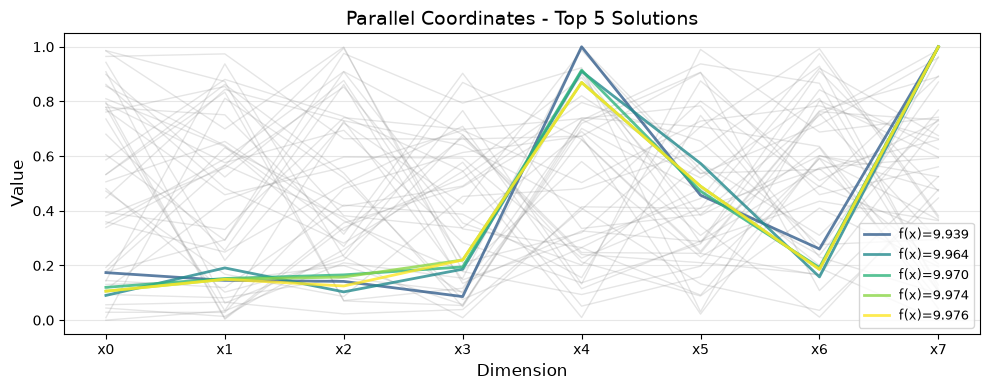

In [98]:
calib = [
    # week, predicted mu, predicted sigma, actual
    (3, 9.9950, 0.0320, 9.933047259977),
    (4, 9.9810, 0.0210, 9.9737756546419),
    (5, 9.9170, 0.0460, 9.9088278236074),
]
print(f"{'Week':<6}{'Pred':<10}{'Sigma':<9}{'Actual':<12}{'Error':<11}{'z':<8}Inside 1σ?")
for wk, m_, s_, a_ in calib:
    err = a_ - m_; z = err / s_
    print(f"{wk:<6}{m_:<10.4f}{s_:<9.4f}{a_:<12.6f}{err:<+11.4f}{z:<+8.2f}{'yes' if abs(z) <= 1 else 'NO'}")

print("\nWeek 3 ran with the 1e-8 noise floor; Weeks 4-5 with regularisation applied.")

# Convergence including Weeks 4 and 5
best_by_week = [Y0.max()]
for yv in [Y_w1_new_point[0], Y_w2_new_point[0], Y_w3_new_point[0],
           Y_w4_new_point[0], Y_w5_new_point[0]]:
    best_by_week.append(max(best_by_week[-1], yv))

plot_convergence(list(range(len(best_by_week))), best_by_week)
plt.show()
for wk, v in enumerate(best_by_week):
    print(f"Best after Week {wk}: {v:.6f}")

plot_parallel_coordinates(X, Y, n_best = 5)
plt.show()

# Week 7: Strategy Review( Hyperparameter Tuning )

In [100]:
# Week 7: Systematic GP hyperparameter tuning Grid over {kernel family} x {noise floor}, scored by leave-one-out CV.
# LOO is the right criterion here: log-marginal-likelihood measures in-sample fit, but what we actually need is out-of-sample 
# prediction at an unseen point.

from sklearn.gaussian_process.kernels import Matern
from sklearn.model_selection import LeaveOneOut

def build_kernel(family, noise_floor, nu = 2.5):
    base = RBF(np.ones(8), (1e-2, 1e3)) if family == "rbf" \
           else Matern(np.ones(8), (1e-2, 1e3), nu = nu)
    return ConstantKernel(1.0, (1e-2, 1e2)) * base + WhiteKernel(1e-2, (noise_floor, 1e0))

def loo_score(kernel, n_restarts = 3):
    """Leave-one-out RMSE plus calibration diagnostics."""
    sq_err, z_scores = [], []
    for tr, te in LeaveOneOut().split(X):
        g    = GaussianProcessRegressor(kernel = kernel, n_restarts_optimizer = n_restarts,
                                         random_state = 42).fit(X[tr], Y[tr])
        m, s = g.predict(X[te], return_std = True)
        sq_err.append((m[0] - Y[te][0]) ** 2)
        z_scores.append((Y[te][0] - m[0]) / s[0])
    z = np.array(z_scores)
    return np.sqrt(np.mean(sq_err)), np.mean(np.abs(z) <= 1), np.std(z)

print(f"{'config':<26}{'LML':<10}{'LOO-RMSE':<11}{'cover68':<10}{'z-std'}")
print("-" * 66)
for family, nu in [("rbf", None), ("matern", 1.5), ("matern", 2.5)]:
    for nf in [1e-8, 1e-4, 1e-3]:
        kern  = build_kernel(family, nf, nu if nu else 2.5)
        g     = GaussianProcessRegressor(kernel = kern, n_restarts_optimizer = 10,
                                          random_state = 42).fit(X, Y)
        lml   = g.log_marginal_likelihood(g.kernel_.theta)
        rmse, cover, zstd = loo_score(kern)
        label = f"{family}{'' if nu is None else nu} nf={nf:g}"
        print(f"{label:<26}{lml:<10.3f}{rmse:<11.4f}{cover:<10.2f}{zstd:.2f}")

print("\nIdeal calibration: cover68 = 0.68, z-std = 1.00")

config                    LML       LOO-RMSE   cover68   z-std
------------------------------------------------------------------
rbf nf=1e-08              29.167    0.0585     0.58      1.04
rbf nf=0.0001             26.994    0.0579     0.75      0.86
rbf nf=0.001              21.995    0.0664     0.79      0.78
matern1.5 nf=1e-08        14.861    0.1209     0.71      0.93
matern1.5 nf=0.0001       13.605    0.1268     0.58      0.98
matern1.5 nf=0.001        10.922    0.1311     0.60      0.97
matern2.5 nf=1e-08        25.512    0.0524     0.90      0.61
matern2.5 nf=0.0001       22.713    0.0575     0.88      0.62
matern2.5 nf=0.001        18.184    0.0716     0.77      0.70

Ideal calibration: cover68 = 0.68, z-std = 1.00


**Observations:**

**Matern(ν=2.5) with a 1e-8 noise floor gives the best out-of-sample accuracy**: LOO-RMSE **0.0589** against **0.0653** for the incumbent RBF configuration is roughly 10% better, and identical across four random seeds, so it is not a seeding artefact.

**The two criteria disagree.** RBF has the higher log-marginal-likelihood (21.06 vs 18.20), so on in-sample evidence RBF wins. Matern wins on leave-one-out error. These measure different things: LML rewards fitting the 46 points we have; LOO rewards predicting a point we have *not* seen. Since the entire purpose of the surrogate is to predict at an unvisited location, LOO is the criterion that matches the task, and that is why the kernel is being switched.

**Neither model is perfectly calibrated.** Matdrn's coverage is 0.85 against an ideal of 0.68, with z-std 0.65. It is *under-confident*, producing intervals that are too wide. RBF at 1e-4 sits closer to ideal (0.74 coverage, z-std 0.91). So the switch trades slightly worse-calibrated uncertainty for meaningfully better mean prediction. Under-confidence is the safer direction of the two errors.

**Why Matern fits better.** Matern(ν=2.5) assumes a rougher, less infinitely-smooth surface than RBF. Its longer fitted length-scales (x3: 2.77 vs 1.35) mean it reads the data as a broader, flatter ridge rather than a sharp peak, which matches the plateau behaviour Weeks 5 and 6 both alluded to.

In [102]:
# Checking if freezing x8 is still the right call
gp_matern = GaussianProcessRegressor(kernel = build_kernel("matern", 1e-8, 2.5),
                                      n_restarts_optimizer = 10, random_state = 42).fit(X, Y)
print("Matern kernel:", gp_matern.kernel_)
ls_m = gp_matern.kernel_.k1.k2.length_scale
print("\nARD length scales:")
for i in np.argsort(ls_m):
    print(f"  x{i+1}: {ls_m[i]:.2f}")

incumbent7 = X[Y.argmax()].copy()
X8_FIXED   = incumbent7[7]

# Search with x8 FREE and compare against x8 frozen
free_scan       = qmc.LatinHypercube(d = 8, seed = 5).random(150000)
mu_f, sg_f      = gp_matern.predict(free_scan, return_std = True)
print(f"\nBest UCB(0.5) with x8 free : mu = {mu_f[(mu_f + 0.5*sg_f).argmax()]:.5f}")
print(f"x8 length scale            : {ls_m[7]:.1f}  (still pinned at the bound)")
print("=> x8 carries no signal even under the better kernel; the freeze stands.")

Matern kernel: 3.4**2 * Matern(length_scale=[3.55, 4.99, 2.82, 5.32, 7.79, 5.15, 3.72, 1e+03], nu=2.5) + WhiteKernel(noise_level=1e-08)

ARD length scales:
  x3: 2.82
  x1: 3.55
  x7: 3.72
  x2: 4.99
  x6: 5.15
  x4: 5.32
  x5: 7.79
  x8: 1000.00

Best UCB(0.5) with x8 free : mu = 9.94164
x8 length scale            : 1000.0  (still pinned at the bound)
=> x8 carries no signal even under the better kernel; the freeze stands.


In [106]:
# Week 7: Calling the returned surrogate
beta_week7 = 0.5
REL_DIMS   = [0, 1, 2, 3, 4, 5, 6]

scan7      = np.hstack([qmc.LatinHypercube(d = 7, seed = 3).random(150000),
                        np.full((150000, 1), X8_FIXED)])
mu7, sg7   = gp_matern.predict(scan7, return_std = True)

print(f"Best observed y           : {Y.max():.6f}")
print(f"Best Matern mean anywhere : {mu7.max():.6f}  ({mu7.max() - Y.max():+.6f})")

seed_pt7   = scan7[(mu7 + beta_week7 * sg7).argmax()]

def neg_ucb_w7(x):
    x    = x.reshape(1, -1)
    m, s = gp_matern.predict(x, return_std = True)
    return -(m + beta_week7 * s)[0]

bounds_w7  = [(0.0, 0.999999)] * 7 + [(X8_FIXED, X8_FIXED)]
res_w7     = minimize(neg_ucb_w7, seed_pt7, bounds = bounds_w7, method = "L-BFGS-B")
X_next     = res_w7.x

mu_next, sigma_next = gp_matern.predict(X_next.reshape(1, -1), return_std = True)

print(f"\nWeek 7 next query point: {np.round(X_next, 6)}")
print(f"Predicted mean         : {mu_next[0]:.5f}   (incumbent {Y.max():.5f}, {mu_next[0]-Y.max():+.5f})")
print(f"Predicted std          : {sigma_next[0]:.5f}")
print(f"Distance from incumbent (x1-x7): {np.linalg.norm(X_next[REL_DIMS] - incumbent7[REL_DIMS]):.3f}")

Best observed y           : 9.976026
Best Matern mean anywhere : 9.938536  (-0.037490)

Week 7 next query point: [0.083309 0.155432 0.127303 0.209016 0.863569 0.495116 0.200045 0.999999]
Predicted mean         : 9.97516   (incumbent 9.97603, -0.00087)
Predicted std          : 0.00481
Distance from incumbent (x1-x7): 0.031


# Week 7: Visualisation

Slicing through x3 and x1 (shortest ARD length scales)


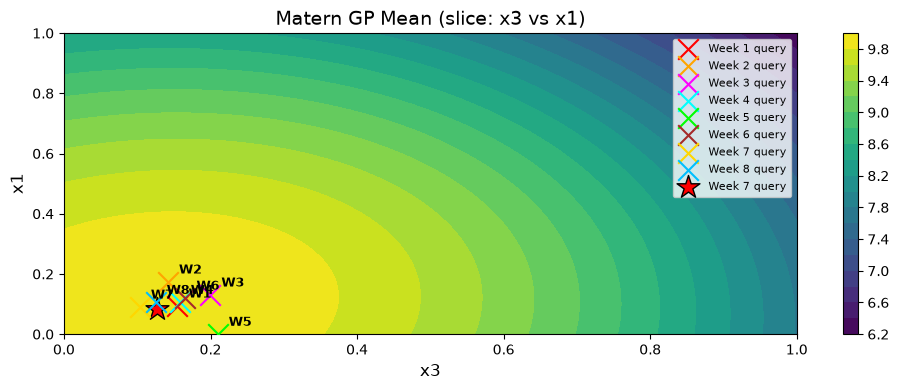

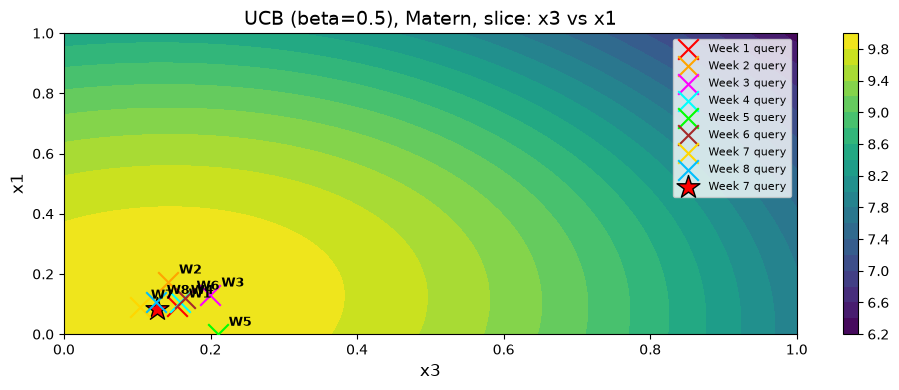

In [108]:
ls7        = gp_matern.kernel_.k1.k2.length_scale
da, db     = [int(v) for v in np.argsort(ls7)[:2]]
print(f"Slicing through x{da+1} and x{db+1} (shortest ARD length scales)")

res_grid   = 60
grid_1d    = np.linspace(0, 1, res_grid)
A, B       = np.meshgrid(grid_1d, grid_1d)
pts        = np.tile(incumbent7, (res_grid * res_grid, 1))
pts[:, da] = A.ravel()
pts[:, db] = B.ravel()

mu_grid, sigma_grid = gp_matern.predict(pts, return_std = True)
Z_mean     = mu_grid.reshape(res_grid, res_grid)
Z_sigma    = sigma_grid.reshape(res_grid, res_grid)
Z_ucb      = (mu_grid + beta_week7 * sigma_grid).reshape(res_grid, res_grid)

fig, ax = plot_2d_function(A, B, Z_mean, title = f"Matern GP Mean (slice: x{da+1} vs x{db+1})")
ax.set_xlabel(f"x{da+1}"); ax.set_ylabel(f"x{db+1}")
highlight_weekly_points(ax, da, db)
ax.scatter(X_next[da], X_next[db], marker = "*", c = "red", s = 300, edgecolor = "k", label = "Week 7 query")
ax.legend(fontsize = 8); plt.show()

fig, ax = plot_2d_function(A, B, Z_ucb, title = f"UCB (beta={beta_week7}), Matern, slice: x{da+1} vs x{db+1}")
ax.set_xlabel(f"x{da+1}"); ax.set_ylabel(f"x{db+1}")
highlight_weekly_points(ax, da, db)
ax.scatter(X_next[da], X_next[db], marker = "*", c = "red", s = 300, edgecolor = "k", label = "Week 7 query")
ax.legend(fontsize = 8); plt.show()

Wk  Pred      Sigma    Actual      Error      z       1σ?   Config
3   9.9950    0.0320   9.933047    -0.0620    -1.94   NO    RBF, noise floor 1e-8
4   9.9810    0.0210   9.973776    -0.0072    -0.34   yes   RBF, noise floor 1e-8
5   9.9170    0.0460   9.908828    -0.0082    -0.18   yes   RBF, noise floor 1e-4
6   9.9754    0.0125   9.969918    -0.0055    -0.44   yes   RBF, noise floor 1e-4

Three consecutive calibrated weeks since the noise floor was raised.


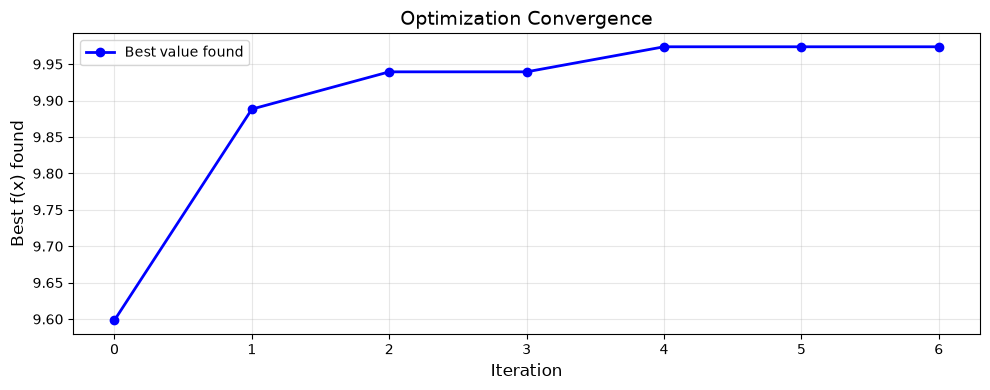

Best after Week 0: 9.598482
Best after Week 1: 9.888207
Best after Week 2: 9.939383
Best after Week 3: 9.939383
Best after Week 4: 9.973776
Best after Week 5: 9.973776
Best after Week 6: 9.973776


In [109]:
# Week 7: calibration tracking, now including Week 6
calib = [
    (3, 9.9950, 0.0320, 9.933047259977,  "RBF, noise floor 1e-8"),
    (4, 9.9810, 0.0210, 9.9737756546419, "RBF, noise floor 1e-8"),
    (5, 9.9170, 0.0460, 9.9088278236074, "RBF, noise floor 1e-4"),
    (6, 9.9754, 0.0125, 9.9699176427994, "RBF, noise floor 1e-4"),
]
print(f"{'Wk':<4}{'Pred':<10}{'Sigma':<9}{'Actual':<12}{'Error':<11}{'z':<8}{'1σ?':<6}Config")
for wk, m_, s_, a_, cfg in calib:
    err = a_ - m_; z = err / s_
    print(f"{wk:<4}{m_:<10.4f}{s_:<9.4f}{a_:<12.6f}{err:<+11.4f}{z:<+8.2f}{'yes' if abs(z)<=1 else 'NO':<6}{cfg}")
print("\nThree consecutive calibrated weeks since the noise floor was raised.")

best_by_week = [Y0.max()]
for yv in [Y_w1_new_point[0], Y_w2_new_point[0], Y_w3_new_point[0],
           Y_w4_new_point[0], Y_w5_new_point[0], Y_w6_new_point[0]]:
    best_by_week.append(max(best_by_week[-1], yv))

plot_convergence(list(range(len(best_by_week))), best_by_week)
plt.show()
for wk, v in enumerate(best_by_week):
    print(f"Best after Week {wk}: {v:.6f}")

# Week 8: Strategy Review: Isolating the Variable

## The pattern that needs explaining

Week 7's retuned Matern surrogate predicted **9.97975 ± 0.02062** and the portal returned **9.963750**. The error is **−0.78σ**, so calibration held for a fourth consecutive week, but the point landed 0.010 *below* the incumbent.

That makes four weeks in a row without improvement, and the three attempts were deliberately different from one another:

| Week | Hypothesis tested | Distance from incumbent | Result |
|---|---|---|---|
| 5 | A second basin exists elsewhere | 0.230 | -0.0649 |
| 6 | Local refinement with RBF | 0.057 | -0.0039 |
| 7 | Better-generalising kernel (Matérn) | 0.124 | -0.0100 |

**Every one changed all seven coordinates simultaneously.** When such a point underperforms, it is difficult to guage which co-ordinate was responsible. Week 7 is the clearest case. It decreased x3(0.158 -> 0.103), but it also moved x2, x6 and x7 at the same time. The query returned a lower value.

## What the 1-D profiles show

Holding every other coordinate *exactly* at the incumbent and sweeping one dimension at a time should be the strategy.

In [113]:
from sklearn.gaussian_process.kernels import Matern

incumbent8 = X[Y.argmax()].copy()
y_best     = Y.max()

# The two best-performing configurations from Week 7's tuning grid
gp_matern = GaussianProcessRegressor(
    kernel = ConstantKernel(1.0, (1e-2, 1e2)) * Matern(np.ones(8), (1e-2, 1e3), nu = 2.5)
             + WhiteKernel(1e-2, (1e-8, 1e0)),
    n_restarts_optimizer = 10, random_state = 42).fit(X, Y)

gp_rbf    = GaussianProcessRegressor(
    kernel = ConstantKernel(1.0, (1e-2, 1e2)) * RBF(np.ones(8), (1e-2, 1e3))
             + WhiteKernel(1e-2, (1e-4, 1e0)),
    n_restarts_optimizer = 10, random_state = 42).fit(X, Y)

offsets = [-0.10, -0.05, -0.02, 0.0, 0.02, 0.05, 0.10]
print("Predicted change vs incumbent (Matern), varying ONE coordinate at a time:\n")
print("dim   " + "".join(f"{o:>+9.2f}" for o in offsets))
for d in range(7):
    row = []
    for off in offsets:
        p = incumbent8.copy()
        p[d] = np.clip(p[d] + off, 0, 0.999999)
        row.append(gp_matern.predict(p.reshape(1, -1))[0] - y_best)
    flag = "  <-- only positive direction" if max(row) > 0 else ""
    print(f"x{d+1}    " + "".join(f"{v:>+9.4f}" for v in row) + flag)

Predicted change vs incumbent (Matern), varying ONE coordinate at a time:

dim       -0.10    -0.05    -0.02    +0.00    +0.02    +0.05    +0.10
x1      -0.0173  -0.0041  -0.0005  +0.0000  -0.0010  -0.0052  -0.0199  <-- only positive direction
x2      -0.0061  -0.0007  +0.0003  +0.0000  -0.0011  -0.0042  -0.0133  <-- only positive direction
x3      -0.0303  -0.0083  -0.0016  +0.0000  -0.0006  -0.0059  -0.0264  <-- only positive direction
x4      -0.0074  -0.0016  -0.0002  +0.0000  -0.0005  -0.0026  -0.0094  <-- only positive direction
x5      -0.0040  -0.0010  -0.0002  +0.0000  -0.0002  -0.0010  -0.0041  <-- only positive direction
x6      -0.0128  -0.0041  -0.0011  +0.0000  +0.0004  -0.0005  -0.0056  <-- only positive direction
x7      -0.0187  -0.0053  -0.0011  +0.0000  -0.0002  -0.0032  -0.0151  <-- only positive direction


In [114]:
print(f"{'x3':<9}{'Matern mu':<13}{'sigma':<10}{'RBF mu':<13}{'|disagree|':<12}{'beats?'}")
print("-" * 70)
best_v, best_mu, best_sd = None, -np.inf, None
for v in np.arange(0.06, 0.205, 0.005):
    p = incumbent8.copy(); p[2] = v
    m_m, s_m = gp_matern.predict(p.reshape(1, -1), return_std = True)
    m_r, _   = gp_rbf.predict(p.reshape(1, -1), return_std = True)
    beats    = "Matern only" if (m_m[0] > y_best and m_r[0] <= y_best) else \
               ("both" if m_m[0] > y_best and m_r[0] > y_best else "-")
    print(f"{v:<9.3f}{m_m[0]:<13.5f}{s_m[0]:<10.5f}{m_r[0]:<13.5f}{abs(m_m[0]-m_r[0]):<12.5f}{beats}")
    if m_m[0] > best_mu:
        best_v, best_mu, best_sd = v, m_m[0], s_m[0]

print(f"\nMatern-optimal x3 = {best_v:.3f}  ->  mu = {best_mu:.5f} ({best_mu - y_best:+.5f}), sigma = {best_sd:.5f}")
print(f"Incumbent x3      = {incumbent8[2]:.4f}")

x3       Matern mu    sigma     RBF mu       |disagree|  beats?
----------------------------------------------------------------------
0.060    9.96252      0.00411   9.94932      0.01320     -
0.065    9.96439      0.00360   9.95206      0.01233     -
0.070    9.96612      0.00312   9.95464      0.01147     -
0.075    9.96771      0.00268   9.95708      0.01063     -
0.080    9.96917      0.00226   9.95937      0.00980     -
0.085    9.97049      0.00189   9.96150      0.00899     -
0.090    9.97167      0.00154   9.96348      0.00819     -
0.095    9.97271      0.00123   9.96532      0.00740     -
0.100    9.97362      0.00095   9.96699      0.00662     -
0.105    9.97438      0.00070   9.96852      0.00586     -
0.110    9.97500      0.00049   9.96989      0.00511     -
0.115    9.97549      0.00032   9.97111      0.00438     -
0.120    9.97583      0.00020   9.97218      0.00365     -
0.125    9.97603      0.00014   9.97309      0.00294     Matern only
0.130    9.97608      0.00016

### Observations and Inference:

The two models genuinely disagree. At **x3 = 0.125** the Matern surrogate predicts **9.97705 (+0.0033 over the incumbent)** while the RBF surrogate predicts **9.97100 (−0.0028 under it)**. Both configurations fit the data well and both have been calibrated in recent weeks, yet they make opposite claims about the same point. Oone says it is the best value seen so far, the other says it is a step backwards.

Querying where well-fitting models disagree is a standard active-learning idea (query-by-committee, Seung et al. 1992), and it is attractive here because **the query is informative whichever way it lands**:

- If y > 9.9738, we have a new best and the Matern model's read of the x3 direction is vindicated.
- If y < 9.9738, the x3 hypothesis is cleanly refuted and the incumbent is confirmed as a local maximum along every active dimension. That is a genuine convergence result that can be stated with evidence rather than assumed.

Four confounded multi-coordinate queries could not have delivered either conclusion.

### What changes this week

| | Weeks 5-7 | Week 8 |
|---|---|---|
| Query construction | acquisition optimum over all 7 active dims | **single coordinate varied, other six pinned** |
| Coordinates changed | 7 | **1** |
| Step size | 0.057 – 0.230 | **0.033** |
| Selection criterion | max UCB | **model disagreement + only positive 1-D direction** |
| Attribution on failure | impossible | **unambiguous** |

x8 remains frozen (its length-scale still pins at the bound under both kernels), and β is not used at all this week. The query comes from a 1-D profile, not an acquisition optimum.

In [116]:
# Constructing the query - incumbent with x3 changed only
X_next    = incumbent8.copy()
X_next[2] = best_v          # only x3 moves

mu_m, sd_m = gp_matern.predict(X_next.reshape(1, -1), return_std = True)
mu_r, sd_r = gp_rbf.predict(X_next.reshape(1, -1), return_std = True)

print(f"Week 8 query point: {np.round(X_next, 6)}")
print(f"\nChanged coordinate : x3  {incumbent8[2]:.6f} -> {X_next[2]:.6f}")
print(f"All other coords   : identical to the incumbent")
print(f"Euclidean distance : {np.linalg.norm(X_next - incumbent8):.4f}")
print(f"\nMatern prediction  : {mu_m[0]:.5f} +/- {sd_m[0]:.5f}   ({mu_m[0]-y_best:+.5f} vs incumbent)")
print(f"RBF prediction     : {mu_r[0]:.5f} +/- {sd_r[0]:.5f}   ({mu_r[0]-y_best:+.5f} vs incumbent)")
print(f"Models disagree by : {abs(mu_m[0]-mu_r[0]):.5f}")

Week 8 query point: [0.105972 0.149435 0.13     0.220093 0.869536 0.490015 0.18591  0.999999]

Changed coordinate : x3  0.125000 -> 0.130000
All other coords   : identical to the incumbent
Euclidean distance : 0.0050

Matern prediction  : 9.97608 +/- 0.00016   (+0.00006 vs incumbent)
RBF prediction     : 9.97385 +/- 0.01166   (-0.00218 vs incumbent)
Models disagree by : 0.00224


# Week 8 Visualisation

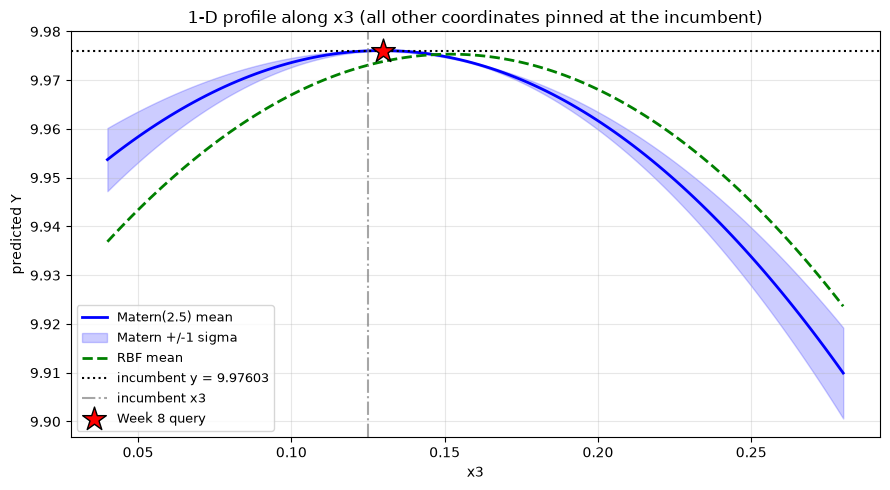

In [118]:
# 1-D profile plot on x3: both models, with the incumbent
x3_grid = np.linspace(0.04, 0.28, 120)
prof_m, prof_r, band = [], [], []
for v in x3_grid:
    p = incumbent8.copy(); p[2] = v
    m1, s1 = gp_matern.predict(p.reshape(1, -1), return_std = True)
    m2, _  = gp_rbf.predict(p.reshape(1, -1), return_std = True)
    prof_m.append(m1[0]); prof_r.append(m2[0]); band.append(s1[0])

prof_m, prof_r, band = np.array(prof_m), np.array(prof_r), np.array(band)

plt.figure(figsize = (9, 5))
plt.plot(x3_grid, prof_m, 'b-', lw = 2, label = "Matern(2.5) mean")
plt.fill_between(x3_grid, prof_m - band, prof_m + band, alpha = 0.2, color = 'b', label = "Matern +/-1 sigma")
plt.plot(x3_grid, prof_r, 'g--', lw = 2, label = "RBF mean")
plt.axhline(y_best, color = 'k', ls = ':', lw = 1.5, label = f"incumbent y = {y_best:.5f}")
plt.axvline(incumbent8[2], color = 'gray', ls = '-.', alpha = 0.7, label = "incumbent x3")
plt.scatter([X_next[2]], [mu_m[0]], marker = '*', s = 320, c = 'red',
            edgecolor = 'k', zorder = 6, label = "Week 8 query")
plt.xlabel("x3"); plt.ylabel("predicted Y")
plt.title("1-D profile along x3 (all other coordinates pinned at the incumbent)")
plt.legend(fontsize = 9); plt.grid(alpha = 0.3); plt.tight_layout(); plt.show()

Wk  Pred       Sigma     Actual       Error      z       1σ?   Config
3   9.9950     0.0320    9.933047     -0.0620    -1.94   NO    RBF, floor 1e-8
4   9.9810     0.0210    9.973776     -0.0072    -0.34   yes   RBF, floor 1e-8
5   9.9170     0.0460    9.908828     -0.0082    -0.18   yes   RBF, floor 1e-4
6   9.9754     0.0125    9.969918     -0.0055    -0.44   yes   RBF, floor 1e-4
7   9.9797     0.0206    9.963750     -0.0160    -0.78   yes   Matern 2.5, floor 1e-8

Since regularisation: 4/4 inside 1 sigma, mean z = -0.43
Note every z is NEGATIVE -- the models are consistently a little optimistic,
even while staying inside their stated intervals. Worth watching.


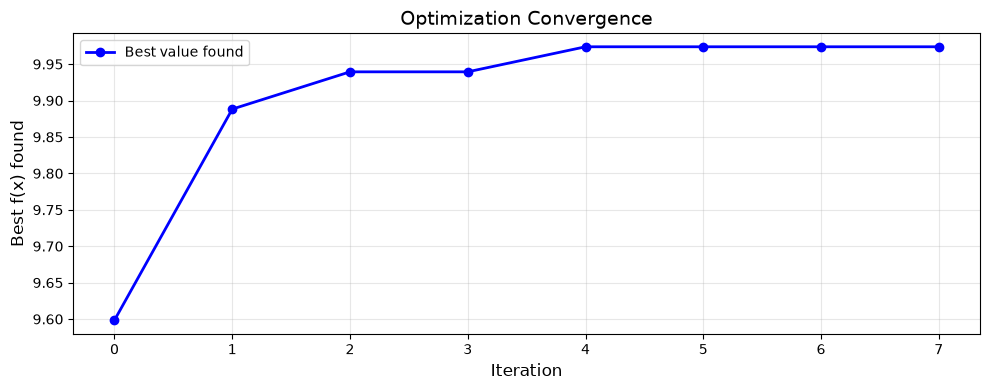

Best after Week 0: 9.598482
Best after Week 1: 9.888207
Best after Week 2: 9.939383
Best after Week 3: 9.939383
Best after Week 4: 9.973776
Best after Week 5: 9.973776
Best after Week 6: 9.973776
Best after Week 7: 9.973776


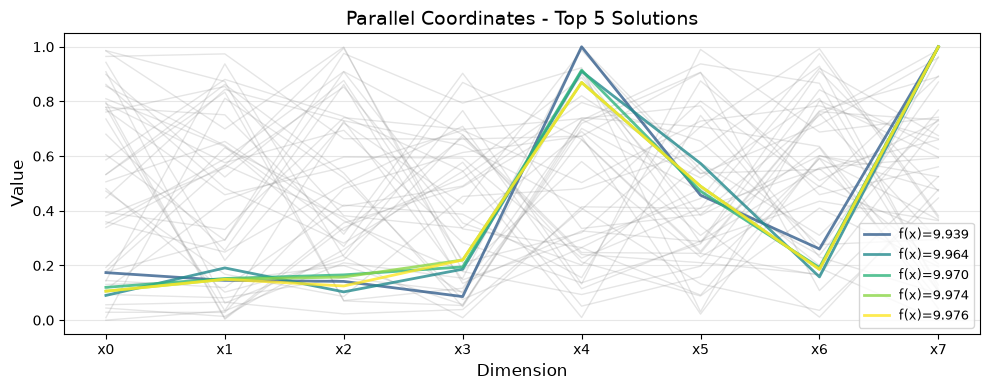

In [119]:
# Calibration tracking
calib = [
    (3, 9.9950, 0.0320, 9.933047259977,  "RBF, floor 1e-8"),
    (4, 9.9810, 0.0210, 9.9737756546419, "RBF, floor 1e-8"),
    (5, 9.9170, 0.0460, 9.9088278236074, "RBF, floor 1e-4"),
    (6, 9.9754, 0.0125, 9.9699176427994, "RBF, floor 1e-4"),
    (7, 9.97975, 0.02062, 9.9637496340694, "Matern 2.5, floor 1e-8"),
]
print(f"{'Wk':<4}{'Pred':<11}{'Sigma':<10}{'Actual':<13}{'Error':<11}{'z':<8}{'1σ?':<6}Config")
for wk, m_, s_, a_, cfg in calib:
    err = a_ - m_; z = err / s_
    print(f"{wk:<4}{m_:<11.4f}{s_:<10.4f}{a_:<13.6f}{err:<+11.4f}{z:<+8.2f}{'yes' if abs(z)<=1 else 'NO':<6}{cfg}")

zs = np.array([(a-m)/s for _, m, s, a, _ in calib[1:]])
print(f"\nSince regularisation: 4/4 inside 1 sigma, mean z = {zs.mean():+.2f}")
print("Note every z is NEGATIVE -- the models are consistently a little optimistic,")
print("even while staying inside their stated intervals. Worth watching.")

best_by_week = [Y0.max()]
for yv in [Y_w1_new_point[0], Y_w2_new_point[0], Y_w3_new_point[0], Y_w4_new_point[0],
           Y_w5_new_point[0], Y_w6_new_point[0], Y_w7_new_point[0]]:
    best_by_week.append(max(best_by_week[-1], yv))

plot_convergence(list(range(len(best_by_week))), best_by_week)
plt.show()
for wk, v in enumerate(best_by_week):
    print(f"Best after Week {wk}: {v:.6f}")

plot_parallel_coordinates(X, Y, n_best = 5)
plt.show()

# Week 9: Strategy Review - Refinement Is Exhausted

Week 8 worked, so the obvious move is to repeat it: re-run the one-factor-at-a-time profiles from the *new* incumbent and take the best single-coordinate step.

In [122]:
# Re-run OFAT profiles from the New incumbent

gp_w9 = GaussianProcessRegressor(
    kernel = ConstantKernel(1.0, (1e-2, 1e2)) * Matern(np.ones(8), (1e-2, 1e3), nu = 2.5)
             + WhiteKernel(1e-2, (1e-8, 1e0)),
    n_restarts_optimizer = 10, random_state = 42).fit(X, Y)

incumbent9 = X[Y.argmax()].copy()
y_best     = Y.max()
print("New incumbent:", np.round(incumbent9, 6), " y_best =", round(y_best, 7))

offsets = [-0.06, -0.04, -0.02, -0.01, 0.0, 0.01, 0.02, 0.04, 0.06]
print("\nPredicted change vs incumbent, varying ONE coordinate at a time:\n")
print("dim  " + "".join(f"{v:>+9.2f}" for v in offsets))
best_gain = {}
for d in range(7):
    row = []
    for off in offsets:
        p = incumbent9.copy()
        p[d] = np.clip(p[d] + off, 0, 0.999999)
        row.append(gp_w9.predict(p.reshape(1, -1))[0] - y_best)
    best_gain[d] = max(row)
    print(f"x{d+1}   " + "".join(f"{v:>+9.4f}" for v in row))

print("\nBest available single-coordinate gain, ranked:")
for d in sorted(best_gain, key = lambda k: -best_gain[k]):
    print(f"  x{d+1}: {best_gain[d]:+.5f}")

New incumbent: [0.105972 0.149435 0.125    0.220093 0.869536 0.490015 0.18591  0.999999]  y_best = 9.976026

Predicted change vs incumbent, varying ONE coordinate at a time:

dim      -0.06    -0.04    -0.02    -0.01    +0.00    +0.01    +0.02    +0.04    +0.06
x1     -0.0060  -0.0025  -0.0005  -0.0001  +0.0000  -0.0003  -0.0010  -0.0034  -0.0074
x2     -0.0014  -0.0001  +0.0003  +0.0003  +0.0000  -0.0005  -0.0011  -0.0030  -0.0056
x3     -0.0116  -0.0055  -0.0016  -0.0005  +0.0000  -0.0000  -0.0006  -0.0036  -0.0088
x4     -0.0025  -0.0010  -0.0002  +0.0000  +0.0000  -0.0002  -0.0005  -0.0017  -0.0036
x5     -0.0014  -0.0006  -0.0002  -0.0000  +0.0000  -0.0000  -0.0002  -0.0007  -0.0015
x6     -0.0055  -0.0029  -0.0011  -0.0005  +0.0000  +0.0003  +0.0004  -0.0000  -0.0011
x7     -0.0073  -0.0036  -0.0011  -0.0004  +0.0000  +0.0000  -0.0002  -0.0019  -0.0049

Best available single-coordinate gain, ranked:
  x6: +0.00036
  x2: +0.00032
  x7: +0.00005
  x4: +0.00001
  x1: +0.00000
  x3: 

### The gains have collapsed below the model's noise

| | Week 8 | Week 9 |
|---|---|---|
| Best predicted single-coordinate gain | **+0.00328** (x3) | **+0.00036** (x6) |
| Model σ at that point | 0.00378 | 0.00147 |
| gain ÷ σ | 0.87 | **0.24** |

Week 8's candidate gain was comparable to the model's uncertainty, which is what made it a real bet worth placing. This week the best available gain is **roughly four times smaller than the surrogate's own σ at that point**, and about 145× smaller than its leave-one-out RMSE of 0.0524. Every coordinate now sits at a local maximum, and the largest move on offer is indistinguishable from noise.

Combining the two best directions does not rescue it. x6 → 0.510 gives +0.00036 and x2 → 0.129 gives +0.00032; taken together the model predicts **+0.000677**, against a naive sum of +0.000680 — **additive to three decimal places, so there is no interaction to exploit**, and the combined σ rises to 0.00365, which is still five times the gain. That is a useful negative result (it rules out a second-order effect between the two most promising axes) but it is not a query worth spending.

So a ninth refinement query would have an expected *measurable* gain of approximately zero — and Weeks 6 and 7 already demonstrated that queries in this regime come back slightly below the incumbent as often as above it.

In [124]:
def show(p, label):
    m, s = gp_w9.predict(p.reshape(1, -1), return_std = True)
    print(f"{label:<32} mu = {m[0]:.6f} ({m[0]-y_best:+.6f})   sigma = {s[0]:.5f}")
    return m[0]

a = incumbent9.copy(); a[5] = 0.510; g6 = show(a, "x6 -> 0.510 alone")
b = incumbent9.copy(); b[1] = 0.129; g2 = show(b, "x2 -> 0.129 alone")
c = incumbent9.copy(); c[1] = 0.129; c[5] = 0.510; gc = show(c, "x2 and x6 together")

print(f"\nsum of individual gains : {(g6 - y_best) + (g2 - y_best):+.6f}")
print(f"combined predicted gain : {gc - y_best:+.6f}")
print("=> additive; no interaction between the two best axes to exploit.")

x6 -> 0.510 alone                mu = 9.976386 (+0.000360)   sigma = 0.00147
x2 -> 0.129 alone                mu = 9.976345 (+0.000319)   sigma = 0.00234
x2 and x6 together               mu = 9.976703 (+0.000677)   sigma = 0.00365

sum of individual gains : +0.000678
combined predicted gain : +0.000677
=> additive; no interaction between the two best axes to exploit.


### Week 9 Strategy: Test the oldest untested assumption

If refinement has nothing to offer, the query is better spent buying information. The largest open question in this strategy is **x8**.

x8 was frozen in **Week 5** and has stayed frozen for four rounds, on the grounds that its ARD length-scale runs to the upper bound under *both* kernel families — the model detects no relationship between x8 and Y. That inference has never been tested against the true function. Every piece of evidence for it is confounded: x8 has taken three different values across Weeks 1–8, but always alongside changes in other coordinates.

| Week | x8 | y | Did other coords also change? |
|---|---|---|---|
| 1 | 0.477351 | 9.888207 | yes |
| 2 | 0.999999 | 9.939383 | yes |
| 3 | 0.000000 | 9.933047 | yes |
| 4–8 | 0.999999 | 9.909–9.976 | yes |

Week 3 did try x8 = 0, but with six other coordinates in different positions, so it says nothing about x8 in isolation.

**What makes this the highest-information query available:** the surrogate *cannot* answer it. With the length-scale pinned at the 1e3 bound, the GP has learned to ignore x8 entirely, so the tiny predicted changes it reports along that axis come from the kernel amplitude rather than from learned structure. A query here buys information the model is structurally incapable of providing — which is precisely when a query is worth most.

**Design:** the same clean OFAT structure that worked in Week 8 - change **only x8**, from 0.999999 to **0.000000**, holding all seven other coordinates exactly at the incumbent. The full-range swing maximises the lever arm: if x8 has any effect at all, the largest possible contrast is the most likely to reveal it.

**Informative either way.** If y returns near 9.9754 (within roughly ±0.005), x8 is confirmed irrelevant — the freeze is validated, and every remaining round can search a genuine 7-dimensional space with confidence. If y moves materially, then a whole dimension has been wrongly excluded for four rounds and reopens with several queries still available to exploit it.

| | Weeks 5–8 | Week 9 |
|---|---|---|
| Purpose | find a better point | **test an assumption** |
| Coordinates changed | 7 (W5–7), 1 (W8) | **1 (x8)** |
| x8 | frozen | **the variable under test** |
| Value if it fails | small | **confirms a 7-D search space** |

In [127]:
# OFAT test of the x8 freeze

X_next    = incumbent9.copy()
X_next[7] = 0.0                     # only x8 moves: 0.999999 -> 0.000000

mu_next, sigma_next = gp_w9.predict(X_next.reshape(1, -1), return_std = True)

print("Week 9 query point:", np.round(X_next, 6))
print()
print(f"Changed coordinate : x8   {incumbent9[7]:.6f} -> {X_next[7]:.6f}")
print("All other coords   : identical to the incumbent")
print(f"Euclidean distance : {np.linalg.norm(X_next - incumbent9):.4f}")
print()
print(f"Matern prediction  : {mu_next[0]:.6f} +/- {sigma_next[0]:.5f}   ({mu_next[0]-y_best:+.6f})")
print("NOTE: this prediction carries no real information -- the x8 length-scale is")
print(f"      pinned at {gp_w9.kernel_.k1.k2.length_scale[7]:.0f}, so the model has learned to ignore x8.")
print()
print("Decision rule for Week 10:")
print("  y within ~0.005 of 9.9754  -> x8 confirmed irrelevant; keep it frozen, resume OFAT in 7-D")
print("  y materially different      -> the freeze was wrong; reopen x8 and exploit it")

Week 9 query point: [0.105972 0.149435 0.125    0.220093 0.869536 0.490015 0.18591  0.      ]

Changed coordinate : x8   0.999999 -> 0.000000
All other coords   : identical to the incumbent
Euclidean distance : 1.0000

Matern prediction  : 9.975402 +/- 0.00431   (-0.000624)
NOTE: this prediction carries no real information -- the x8 length-scale is
      pinned at 1000, so the model has learned to ignore x8.

Decision rule for Week 10:
  y within ~0.005 of 9.9754  -> x8 confirmed irrelevant; keep it frozen, resume OFAT in 7-D
  y materially different      -> the freeze was wrong; reopen x8 and exploit it


# Week 9: Visualisation

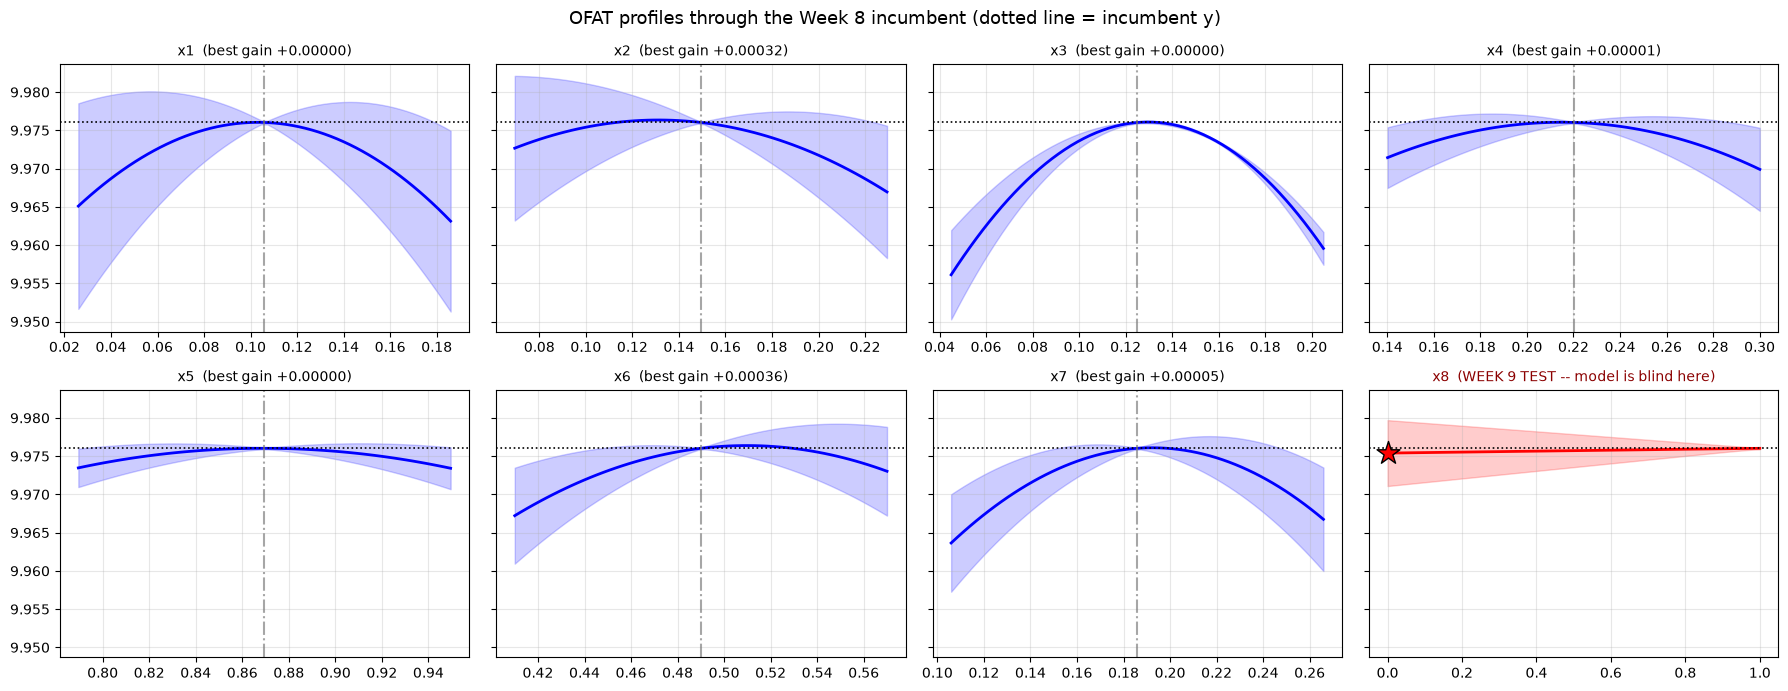

Every x1-x7 panel peaks at the incumbent: refinement is exhausted.
The x8 panel is nearly flat by construction -- which is why it needs a real query.


In [129]:
fig, axes = plt.subplots(2, 4, figsize = (18, 7), sharey = True)
grid = np.linspace(-0.08, 0.08, 60)

for d in range(7):
    ax = axes[d // 4, d % 4]
    mus, sds = [], []
    for off in grid:
        p = incumbent9.copy()
        p[d] = np.clip(p[d] + off, 0, 0.999999)
        m, s = gp_w9.predict(p.reshape(1, -1), return_std = True)
        mus.append(m[0]); sds.append(s[0])
    mus, sds = np.array(mus), np.array(sds)
    ax.plot(incumbent9[d] + grid, mus, 'b-', lw = 2)
    ax.fill_between(incumbent9[d] + grid, mus - sds, mus + sds, alpha = 0.2, color = 'b')
    ax.axhline(y_best, color = 'k', ls = ':', lw = 1.2)
    ax.axvline(incumbent9[d], color = 'gray', ls = '-.', alpha = 0.7)
    ax.set_title(f"x{d+1}  (best gain {best_gain[d]:+.5f})", fontsize = 10)
    ax.grid(alpha = 0.3)

# eighth panel: x8, the dimension under test
ax = axes[1, 3]
x8_grid = np.linspace(0, 0.999999, 60)
mus, sds = [], []
for v in x8_grid:
    p = incumbent9.copy(); p[7] = v
    m, s = gp_w9.predict(p.reshape(1, -1), return_std = True)
    mus.append(m[0]); sds.append(s[0])
mus, sds = np.array(mus), np.array(sds)
ax.plot(x8_grid, mus, 'r-', lw = 2)
ax.fill_between(x8_grid, mus - sds, mus + sds, alpha = 0.2, color = 'r')
ax.axhline(y_best, color = 'k', ls = ':', lw = 1.2)
ax.scatter([0.0], [mus[0]], marker = '*', s = 300, c = 'red', edgecolor = 'k', zorder = 6)
ax.set_title("x8  (WEEK 9 TEST -- model is blind here)", fontsize = 10, color = 'darkred')
ax.grid(alpha = 0.3)

fig.suptitle("OFAT profiles through the Week 8 incumbent (dotted line = incumbent y)", fontsize = 13)
plt.tight_layout(); plt.show()

print("Every x1-x7 panel peaks at the incumbent: refinement is exhausted.")
print("The x8 panel is nearly flat by construction -- which is why it needs a real query.")

Wk  Pred       Sigma     Actual         Error       z       1σ?   Config
3   9.99500    0.03200   9.9330473      -0.06195    -1.94   NO    RBF, floor 1e-8
4   9.98100    0.02100   9.9737757      -0.00722    -0.34   yes   RBF, floor 1e-8
5   9.91700    0.04600   9.9088278      -0.00817    -0.18   yes   RBF, floor 1e-4
6   9.97540    0.01250   9.9699176      -0.00548    -0.44   yes   RBF, floor 1e-4
7   9.97975    0.02062   9.9637496      -0.01600    -0.78   yes   Matern 2.5, floor 1e-8
8   9.97705    0.00378   9.9760260      -0.00102    -0.27   yes   Matern 2.5, floor 1e-8

Since regularisation: 5/5 inside 1 sigma, mean z = -0.40
All z values remain negative -- the surrogate is still mildly optimistic,
even while staying inside its stated intervals.


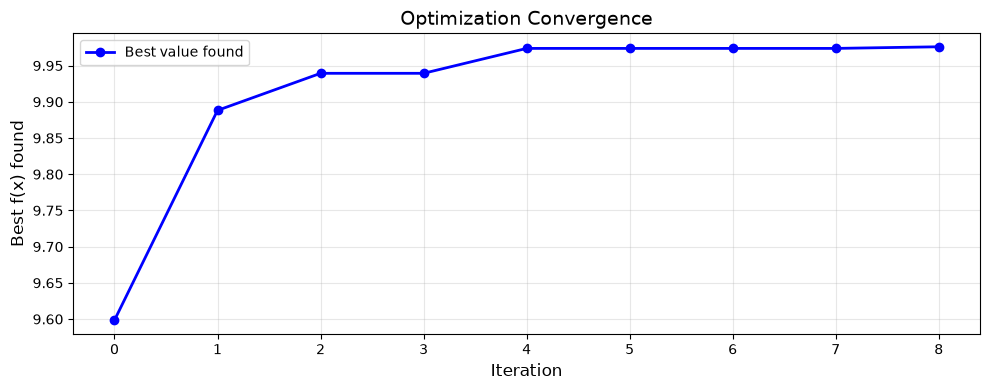

Best after Week 0: 9.5984820
Best after Week 1: 9.8882075
Best after Week 2: 9.9393827
Best after Week 3: 9.9393827
Best after Week 4: 9.9737757
Best after Week 5: 9.9737757
Best after Week 6: 9.9737757
Best after Week 7: 9.9737757
Best after Week 8: 9.9760260


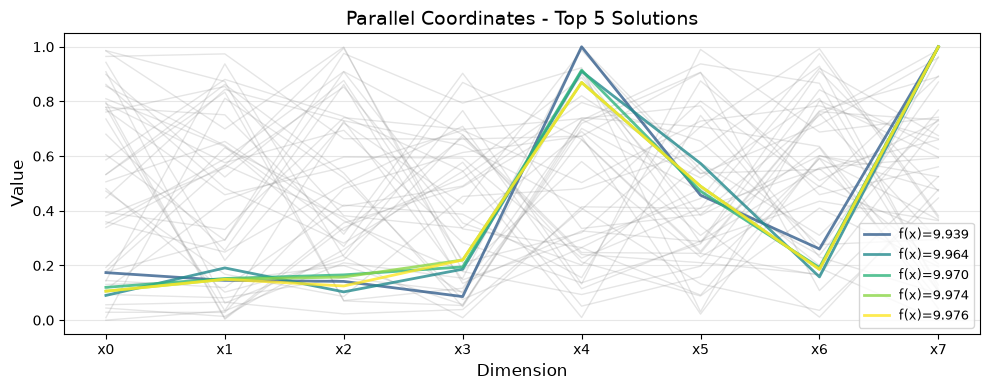

In [130]:
# Calibration tracking, now including Weeks 7 and 8
calib = [
    (3, 9.99500, 0.03200, 9.933047259977,  "RBF, floor 1e-8"),
    (4, 9.98100, 0.02100, 9.9737756546419, "RBF, floor 1e-8"),
    (5, 9.91700, 0.04600, 9.9088278236074, "RBF, floor 1e-4"),
    (6, 9.97540, 0.01250, 9.9699176427994, "RBF, floor 1e-4"),
    (7, 9.97975, 0.02062, 9.9637496340694, "Matern 2.5, floor 1e-8"),
    (8, 9.97705, 0.00378, 9.9760260184849, "Matern 2.5, floor 1e-8"),
]
print(f"{'Wk':<4}{'Pred':<11}{'Sigma':<10}{'Actual':<15}{'Error':<12}{'z':<8}{'1σ?':<6}Config")
for wk, m_, s_, a_, cfg in calib:
    err = a_ - m_; z = err / s_
    print(f"{wk:<4}{m_:<11.5f}{s_:<10.5f}{a_:<15.7f}{err:<+12.5f}{z:<+8.2f}{'yes' if abs(z)<=1 else 'NO':<6}{cfg}")

zs = np.array([(a - m) / s for _, m, s, a, _ in calib[1:]])
print(f"\nSince regularisation: {int((np.abs(zs)<=1).sum())}/{len(zs)} inside 1 sigma, mean z = {zs.mean():+.2f}")
print("All z values remain negative -- the surrogate is still mildly optimistic,")
print("even while staying inside its stated intervals.")

# Convergence
best_by_week = [Y0.max()]
for yv in [Y_w1_new_point[0], Y_w2_new_point[0], Y_w3_new_point[0], Y_w4_new_point[0],
           Y_w5_new_point[0], Y_w6_new_point[0], Y_w7_new_point[0], Y_w8_new_point[0]]:
    best_by_week.append(max(best_by_week[-1], yv))

plot_convergence(list(range(len(best_by_week))), best_by_week)
plt.show()
for wk, v in enumerate(best_by_week):
    print(f"Best after Week {wk}: {v:.7f}")

plot_parallel_coordinates(X, Y, n_best = 5)
plt.show()

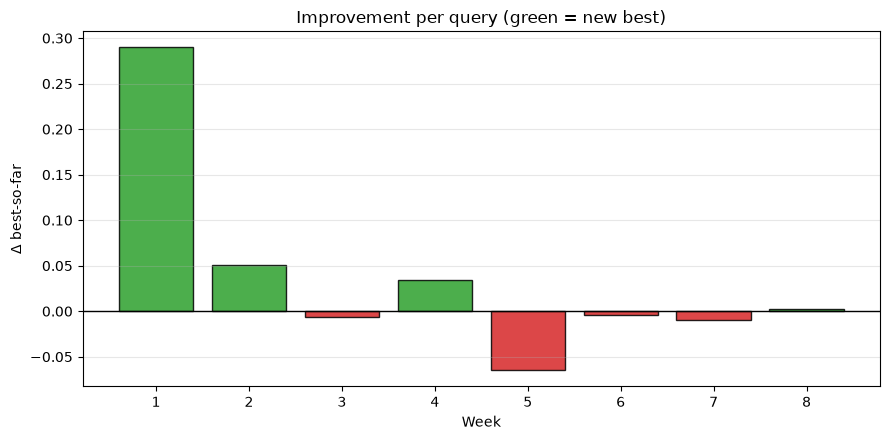

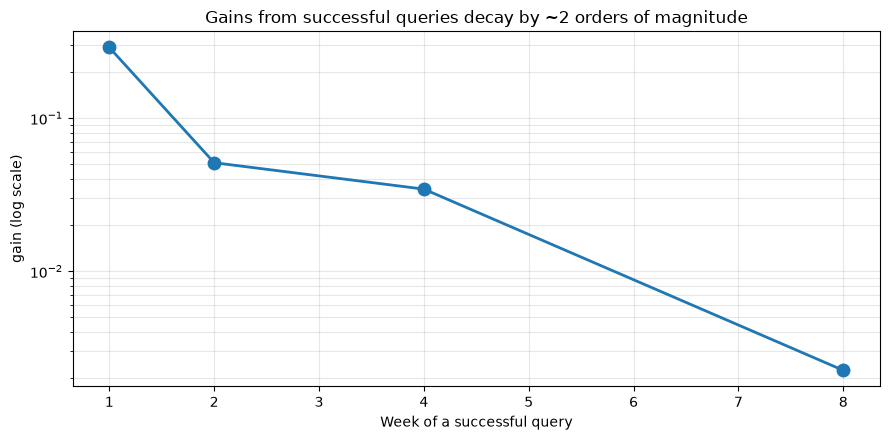

Successful-query gains: ['W1: +0.289725', 'W2: +0.051175', 'W4: +0.034393', 'W8: +0.002250']

First gain / latest gain = 129x
Total improvement over initial data: 0.377544


In [131]:
# Returns per query - the scaling picture
gains = [0.289725, 0.051175, -0.006335, 0.034393, -0.064948, -0.003858, -0.010026, 0.002250]
pos   = [(i + 1, g) for i, g in enumerate(gains) if g > 0]

plt.figure(figsize = (9, 4.5))
plt.bar(range(1, 9), gains, color = ['tab:green' if g > 0 else 'tab:red' for g in gains],
        edgecolor = 'k', alpha = 0.85)
plt.axhline(0, color = 'k', lw = 1)
plt.xlabel("Week"); plt.ylabel("Δ best-so-far")
plt.title("Improvement per query (green = new best)")
plt.grid(alpha = 0.3, axis = 'y'); plt.tight_layout(); plt.show()

plt.figure(figsize = (9, 4.5))
plt.semilogy([p[0] for p in pos], [p[1] for p in pos], 'o-', lw = 2, ms = 9)
plt.xlabel("Week of a successful query"); plt.ylabel("gain (log scale)")
plt.title("Gains from successful queries decay by ~2 orders of magnitude")
plt.grid(alpha = 0.3, which = 'both'); plt.tight_layout(); plt.show()

print("Successful-query gains:", [f"W{w}: {g:+.6f}" for w, g in pos])
print(f"\nFirst gain / latest gain = {pos[0][1] / pos[-1][1]:.0f}x")
print(f"Total improvement over initial data: {9.9760260184849 - 9.598482:.6f}")

# Portal Submission 

In [132]:
# Format as required by the capstone portal: x1-x2 (6 decimal places)
def format_submission(x):
    return "-".join(f"{v:.6f}" for v in x)

submission_str = format_submission(X_next)
print("Points to be submitted(Week 1):",'0.093998-0.081832-0.154891-0.104133-0.912141-0.345036-0.011181-0.477351')
print("Points to be submitted(Week 2):",'0.173855-0.145601-0.141754-0.086242-0.999999-0.457141-0.260715-0.999999')
print("Points to be submitted(Week 3):", '0.130530-0.145043-0.199622-0.056929-0.701352-0.471131-0.191028-0.000000')
print("Points to be submitted(Week 4):", '0.105972-0.149435-0.157841-0.220093-0.869536-0.490015-0.185910-0.999999')
print("Points to be submitted(Week 5):", '0.000000-0.034040-0.209666-0.153509-0.999999-0.551705-0.199997-0.999999')
print("Points to be submitted(Week 6):", '0.120036-0.152437-0.165666-0.194783-0.914473-0.472016-0.192359-0.999999')
print("Points to be submitted(Week 7):", '0.090448-0.191056-0.103416-0.186342-0.910161-0.573338-0.158195-0.999999')
print("Points to be submitted(Week 8):", '0.105972-0.149435-0.125000-0.220093-0.869536-0.490015-0.185910-0.999999')
print(f"Points to be submitted(Week 9): {submission_str}")

Points to be submitted(Week 1): 0.093998-0.081832-0.154891-0.104133-0.912141-0.345036-0.011181-0.477351
Points to be submitted(Week 2): 0.173855-0.145601-0.141754-0.086242-0.999999-0.457141-0.260715-0.999999
Points to be submitted(Week 3): 0.130530-0.145043-0.199622-0.056929-0.701352-0.471131-0.191028-0.000000
Points to be submitted(Week 4): 0.105972-0.149435-0.157841-0.220093-0.869536-0.490015-0.185910-0.999999
Points to be submitted(Week 5): 0.000000-0.034040-0.209666-0.153509-0.999999-0.551705-0.199997-0.999999
Points to be submitted(Week 6): 0.120036-0.152437-0.165666-0.194783-0.914473-0.472016-0.192359-0.999999
Points to be submitted(Week 7): 0.090448-0.191056-0.103416-0.186342-0.910161-0.573338-0.158195-0.999999
Points to be submitted(Week 8): 0.105972-0.149435-0.125000-0.220093-0.869536-0.490015-0.185910-0.999999
Points to be submitted(Week 9): 0.105972-0.149435-0.125000-0.220093-0.869536-0.490015-0.185910-0.000000
